# CR-39 radon track analysis — from ImageJ macro to neural networks

This notebook implements the 3-step plan to replace the "dumb" ImageJ `Analyze Particles` macro
with a smarter, NN-based pipeline for counting alpha-particle tracks in CR-39 detector scans.

**Steps**
1. **Baseline (classical).** Reproduce the macro count, then build an *improved* classical detector
   (adaptive threshold, **no circularity filter**, watershed splitting of touching tracks).
   Quantify how many real tracks the macro silently drops.
2. **Cellpose-SAM baseline.** Pretrained instance segmentation that splits touching objects — a strong,
   near-zero-training counter to beat the macro.
3. **Unsupervised pipeline (the \"smart\" version).** Convolutional autoencoder on track candidate patches
   → embeddings → clustering. Separates real tracks from dust/scratches *and* discovers track-type
   morphology (alpha energy/angle) **without any manual labels**.

**Environment.** Run with the `Python (pytmetalbeta · MPS)` kernel. Stack: torch (Apple MPS GPU),
numpy, scipy, scikit-image, scikit-learn, matplotlib, pandas, cellpose 4.x.

> Validation philosophy: this is a *measurement* pipeline. Treat every automatic count as a hypothesis
> and sanity-check it against hand counts on a couple of crops before trusting global numbers.

## Step 0 — Setup, configuration and image I/O

The `CONFIG` cell centralises every tunable: paths, the ROI rectangle (copied verbatim from the macro:
`makeRectangle(2188, 2244, 5072, 4960)`), the detector thresholds, and the patch / training settings.
Change values here, re-run, done.

In [40]:
from __future__ import annotations
import os, glob, math, json, time, warnings
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None  # the scans are ~9448x9448, above PIL's default safety cap

warnings.filterwarnings("ignore")  # keep the notebook output focused on results

@dataclass
class Config:
    # --- paths (relative to the repo root; notebook lives in algorithms/) ---
    repo_root: Path = Path("..").resolve()
    data_dir: Path = field(init=False)
    out_dir: Path = field(init=False)
    macro_summary: Path = field(init=False)

    # --- ROI: exactly the macro's makeRectangle(x, y, w, h) ---
    roi_x: int = 2188
    roi_y: int = 2244
    roi_w: int = 5072
    roi_h: int = 4960

    # --- macro reproduction (Analyze Particles size=20-250 circularity=0.7-1.00, threshold 1..255) ---
    macro_thresh: int = 1            # setThreshold(1, 255) -> foreground is pixel >= 1
    macro_size_min: int = 20
    macro_size_max: int = 250
    macro_circ_min: float = 0.70
    macro_circ_max: float = 1.00

    # --- improved classical detector ---
    # NOTE: inside the macro ROI the background is clean 0 and tracks are very dim (max ~25-56),
    # so the foreground threshold is >= 1, exactly like the macro's setThreshold(1, 255).
    det_min_area: int = 20           # drop sub-track speckle (matches macro size lower bound)
    det_max_area: int = 100000       # effectively no upper cap (we split merged blobs instead of rejecting)
    det_thresh_mode: str = "fixed"   # "fixed" | "otsu"
    det_fixed_thresh: int = 1        # pixel >= 1 (foreground), i.e. ROI background is exactly 0
    det_split_touching: bool = True  # watershed-split only *merged* blobs (area > det_split_area)
    det_split_area: int = 160        # only blobs bigger than this are candidates for splitting
    det_split_min_area: int = 20     # discard watershed fragments smaller than this (px)

    # --- patch extraction for the autoencoder ---
    patch_size: int = 48
    max_patches: int = 20000         # cap for memory/speed

    # --- autoencoder training ---
    latent_dim: int = 32
    ae_epochs: int = 25
    ae_batch: int = 256
    ae_lr: float = 1e-3
    seed: int = 0

    # --- clustering ---
    n_clusters: int = 6

    def __post_init__(self):
        self.data_dir = self.repo_root / "data_test"
        self.out_dir = self.repo_root / "algorithms" / "outputs"
        self.macro_summary = self.data_dir / "Summary.csv"
        self.out_dir.mkdir(parents=True, exist_ok=True)

    @property
    def roi_slice(self):
        return (slice(self.roi_y, self.roi_y + self.roi_h),
                slice(self.roi_x, self.roi_x + self.roi_w))

CFG = Config()
np.random.seed(CFG.seed)

def list_images(cfg: Config = CFG):
    files = sorted(glob.glob(str(cfg.data_dir / "*.jpg")))
    return [Path(f) for f in files]

def load_gray(path, cfg: Config = CFG) -> np.ndarray:
    """Load a scan as a uint8 grayscale array."""
    return np.asarray(Image.open(path).convert("L"))

def load_roi(path, cfg: Config = CFG) -> np.ndarray:
    return load_gray(path, cfg)[cfg.roi_slice]

IMAGES = list_images()
print(f"repo_root : {CFG.repo_root}")
print(f"data_dir  : {CFG.data_dir}")
print(f"out_dir   : {CFG.out_dir}")
print(f"found {len(IMAGES)} images:", [p.name for p in IMAGES])
print(f"ROI (x,y,w,h) = ({CFG.roi_x},{CFG.roi_y},{CFG.roi_w},{CFG.roi_h})")

repo_root : /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon
data_dir  : /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/data_test
out_dir   : /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/algorithms/outputs
found 15 images: ['LBS255611.jpg', 'LBS255612.jpg', 'LBS255613.jpg', 'LBS255614.jpg', 'LBS255615.jpg', 'LBS255616.jpg', 'LBS255617.jpg', 'LBS255618.jpg', 'LBS255619.jpg', 'LBS255620.jpg', 'LBS255621.jpg', 'LBS255622.jpg', 'LBS255623.jpg', 'LBS255624.jpg', 'LBS255625.jpg']
ROI (x,y,w,h) = (2188,2244,5072,4960)


torch 2.8.0.dev20250318 | device: mps

ROI shape (4960, 5072)  min=0 max=25 mean=0.006
  fraction of pixels > 0: 0.3532%
  fraction of pixels > 1: 0.1250%
  fraction of pixels > 2: 0.0470%
  fraction of pixels > 3: 0.0233%
  fraction of pixels > 5: 0.0106%
  fraction of pixels > 8: 0.0058%


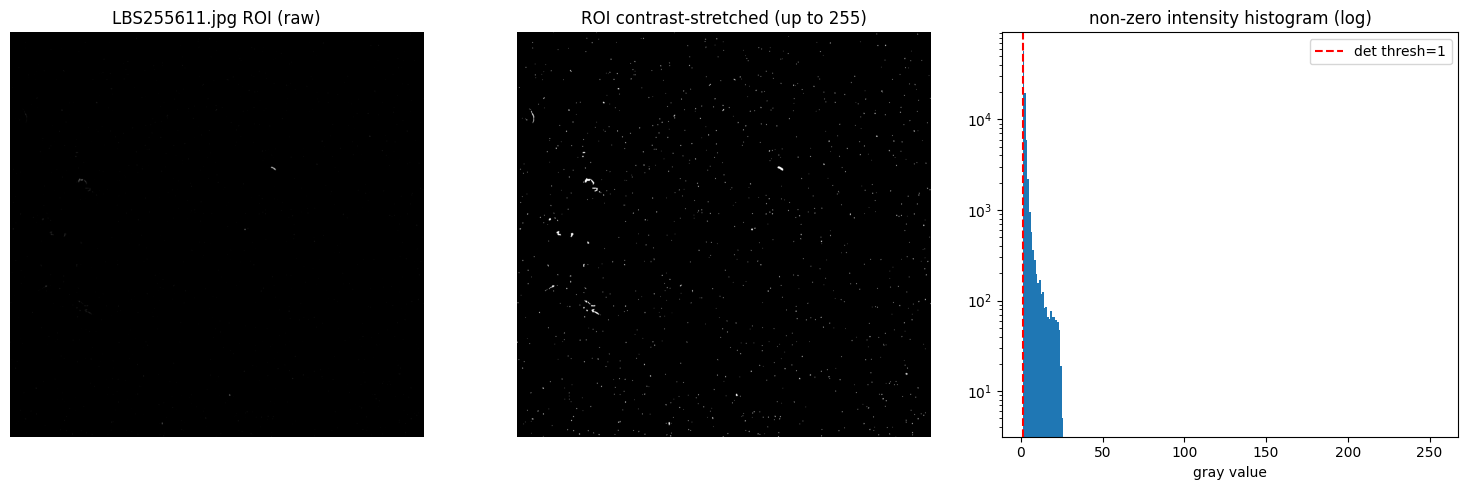

In [41]:
import torch
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

# --- quick look at one ROI: intensity statistics justify the detector threshold ---
# Inside the macro ROI the background is exactly 0 and tracks are dim (a few -> ~50 gray levels);
# the bright (254) pixels in the full scan are the scanner border OUTSIDE this ROI.
roi0 = load_roi(IMAGES[0])
print(f"\nROI shape {roi0.shape}  min={roi0.min()} max={roi0.max()} mean={roi0.mean():.3f}")
for t in (0, 1, 2, 3, 5, 8):
    print(f"  fraction of pixels > {t}: {(roi0 > t).mean():.4%}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(roi0, cmap="gray"); ax[0].set_title(f"{IMAGES[0].name} ROI (raw)")
ax[1].imshow(np.clip(roi0.astype(int) * 255, 0, 255), cmap="gray")
ax[1].set_title("ROI contrast-stretched (up to 255)")
nz = roi0[roi0 > 0]
ax[2].hist(nz, bins=range(1, 256), log=True)
ax[2].axvline(CFG.det_fixed_thresh, color="r", ls="--", label=f"det thresh={CFG.det_fixed_thresh}")
ax[2].set_title("non-zero intensity histogram (log)"); ax[2].set_xlabel("gray value"); ax[2].legend()
for a in ax[:2]: a.axis("off")
plt.tight_layout(); plt.show()

## Step 1 — Classical baseline: reproduce the macro, then beat it

Two detectors on the same ROI:

- **`macro_count`** — faithful re-implementation of `Analyze Particles size=20-250 circularity=0.7-1.00`
  on a `>= 1` threshold. Used to *validate* against the macro's `Summary.csv`.
- **`improved_detect`** — adaptive/robust threshold, **area filter but no circularity gate**, and
  **watershed splitting** of touching tracks. This is the high-recall candidate generator that also
  feeds Step 3.

The gap `improved − macro` is, in large part, the population of **oblique (elongated) tracks the
circularity filter throws away** plus **merged tracks the size cap rejected** — i.e. real signal the
macro loses.

`circularity = 4π·area / perimeter²` (1.0 = perfect disc), matching ImageJ's definition.

In [84]:
from skimage import measure, morphology, segmentation, filters
from scipy import ndimage as ndi

def _circularity(area, perimeter):
    if perimeter <= 0:
        return 0.0
    c = 4.0 * math.pi * area / (perimeter ** 2)
    return min(c, 1.0)  # ImageJ clamps to 1.0

def macro_count(roi: np.ndarray, cfg: Config = CFG) -> int:
    """Re-implement ImageJ Analyze Particles (size + circularity gate) to validate vs Summary.csv."""
    mask = roi >= cfg.macro_thresh
    lbl = measure.label(mask, connectivity=2)  # ImageJ uses 8-connectivity
    n = 0
    for p in measure.regionprops(lbl):
        if cfg.macro_size_min <= p.area <= cfg.macro_size_max:
            if cfg.macro_circ_min <= _circularity(p.area, p.perimeter) <= cfg.macro_circ_max:
                n += 1
    return n

from skimage.feature import peak_local_max

def _split_blob(region_mask):
    """Watershed-split a single boolean blob; return a labeled array (1..n)."""
    dist = ndi.distance_transform_edt(region_mask)
    coords = peak_local_max(dist, min_distance=3, labels=region_mask, exclude_border=False)
    if len(coords) <= 1:
        return region_mask.astype(np.int32)
    mk = np.zeros(region_mask.shape, np.int32)
    for j, (r, c) in enumerate(coords, start=1):
        mk[r, c] = j
    mk, _ = ndi.label(mk > 0)
    return segmentation.watershed(-dist, mk, mask=region_mask)

def improved_detect(roi: np.ndarray, cfg: Config = CFG):
    """High-recall detector: foreground threshold, area filter, NO circularity gate,
    and watershed splitting applied ONLY to merged blobs (area > det_split_area) so that
    single elongated/oblique tracks are kept intact.  Fragments produced by watershed
    with area < det_split_min_area are discarded (default 20 px; change in Config).

    Returns (labels, regionprops_list).
    """
    if cfg.det_thresh_mode == "otsu":
        nz = roi[roi > 0]
        thr = int(filters.threshold_otsu(nz)) if nz.size else 1
    else:
        thr = cfg.det_fixed_thresh
    mask = roi >= thr
    mask = morphology.remove_small_objects(mask, min_size=cfg.det_min_area)
    mask = morphology.remove_small_holes(mask, area_threshold=16)

    labels0 = measure.label(mask, connectivity=2)  # 8-connectivity like ImageJ
    out = np.zeros_like(labels0, dtype=np.int32)
    nxt = 1
    for i, sl in enumerate(ndi.find_objects(labels0), start=1):
        if sl is None:
            continue
        reg = labels0[sl] == i
        area = int(reg.sum())
        if cfg.det_split_touching and area > cfg.det_split_area:
            ws = _split_blob(reg)
            for lab in range(1, int(ws.max()) + 1):
                frag = ws == lab
                if int(frag.sum()) < cfg.det_split_min_area:
                    continue  # discard tiny watershed fragment
                out[sl][frag] = nxt; nxt += 1
        else:
            out[sl][reg] = nxt; nxt += 1

    props = [p for p in measure.regionprops(out, intensity_image=roi)
             if cfg.det_min_area <= p.area <= cfg.det_max_area]
    return out, props

print("Step 1 detectors defined.")

Step 1 detectors defined.


In [43]:
# Run both detectors on every image and compare against the macro's Summary.csv
macro_csv = pd.read_csv(CFG.macro_summary)
macro_map = dict(zip(macro_csv["Slice"], macro_csv["Count"]))

rows = []
detect_cache = {}  # name -> (labels, props), reused by Step 3
for path in IMAGES:
    roi = load_roi(path)
    mc = macro_count(roi)
    labels, props = improved_detect(roi)
    detect_cache[path.name] = (labels, props)
    rows.append({
        "image": path.name,
        "imagej_count": macro_map.get(path.name, np.nan),
        "macro_repro": mc,
        "improved": len(props),
    })
    print(f"{path.name}: ImageJ={macro_map.get(path.name)}, repro={mc}, improved={len(props)}")

base = pd.DataFrame(rows)
base["repro_err_%"] = 100 * (base["macro_repro"] - base["imagej_count"]) / base["imagej_count"]
base["extra_vs_macro"] = base["improved"] - base["imagej_count"]
base["extra_%"] = 100 * base["extra_vs_macro"] / base["imagej_count"]
base.to_csv(CFG.out_dir / "step1_counts.csv", index=False)
base

LBS255611.jpg: ImageJ=795, repro=896, improved=1114
LBS255612.jpg: ImageJ=752, repro=842, improved=1044
LBS255613.jpg: ImageJ=729, repro=799, improved=954
LBS255614.jpg: ImageJ=713, repro=787, improved=916
LBS255615.jpg: ImageJ=719, repro=801, improved=906
LBS255616.jpg: ImageJ=640, repro=705, improved=783
LBS255617.jpg: ImageJ=810, repro=907, improved=1055
LBS255618.jpg: ImageJ=668, repro=747, improved=860
LBS255619.jpg: ImageJ=739, repro=842, improved=990
LBS255620.jpg: ImageJ=786, repro=880, improved=1068
LBS255621.jpg: ImageJ=766, repro=865, improved=971
LBS255622.jpg: ImageJ=829, repro=928, improved=1131
LBS255623.jpg: ImageJ=744, repro=837, improved=992
LBS255624.jpg: ImageJ=804, repro=898, improved=1195
LBS255625.jpg: ImageJ=784, repro=869, improved=1009


,image,imagej_count,macro_repro,improved,repro_err_%,extra_vs_macro,extra_%
0,LBS255611.jpg,795,896,1114,12.704403,319,40.125786
1,LBS255612.jpg,752,842,1044,11.968085,292,38.829787
2,LBS255613.jpg,729,799,954,9.602195,225,30.864198
3,LBS255614.jpg,713,787,916,10.378682,203,28.471248
4,LBS255615.jpg,719,801,906,11.404729,187,26.008345
5,LBS255616.jpg,640,705,783,10.156250,143,22.343750
6,LBS255617.jpg,810,907,1055,11.975309,245,30.246914
7,LBS255618.jpg,668,747,860,11.826347,192,28.742515
8,LBS255619.jpg,739,842,990,13.937754,251,33.964817
9,LBS255620.jpg,786,880,1068,11.959288,282,35.877863


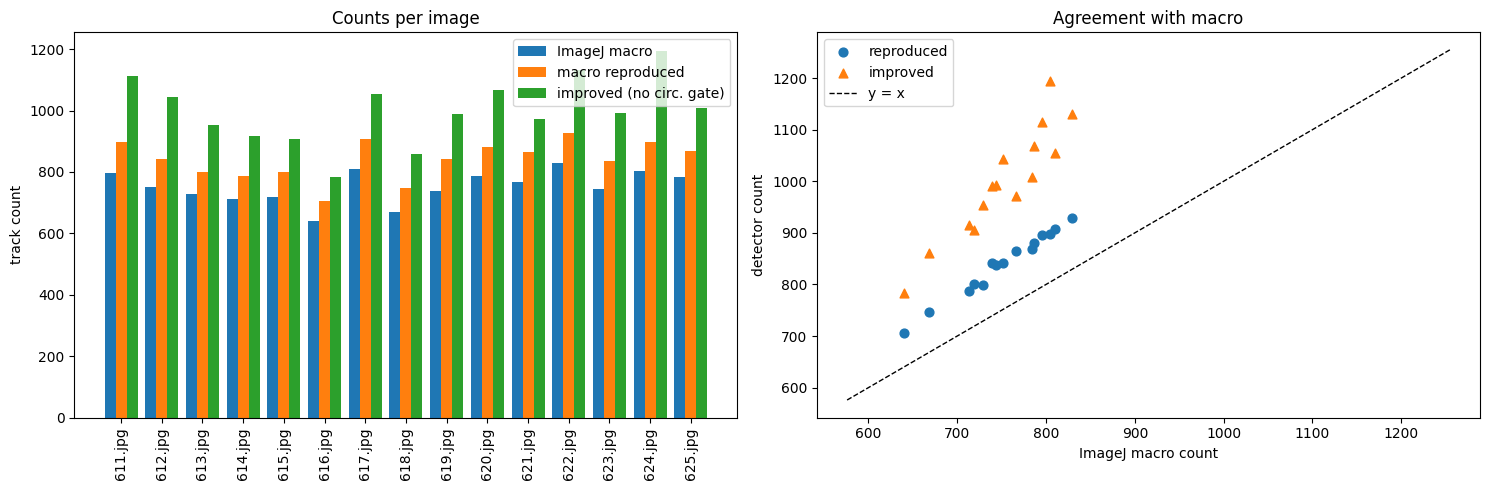

Macro reproduction error: mean +11.7%  (|err| 11.7%) — should be small if our re-impl is faithful.
Improved detector finds on average +32.6% more candidates than the macro.


In [85]:
# Visual diagnostics for Step 1
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(base))
w = 0.27
ax[0].bar(x - w, base["imagej_count"], w, label="ImageJ macro")
ax[0].bar(x,      base["macro_repro"], w, label="macro reproduced")
ax[0].bar(x + w,  base["improved"],   w, label="improved (no circ. gate)")
ax[0].set_xticks(x); ax[0].set_xticklabels([n[-7:] for n in base["image"]], rotation=90)
ax[0].set_ylabel("track count"); ax[0].legend(); ax[0].set_title("Counts per image")

ax[1].scatter(base["imagej_count"], base["macro_repro"], label="reproduced", s=40)
ax[1].scatter(base["imagej_count"], base["improved"], label="improved", s=40, marker="^")
lims = [base["imagej_count"].min() * 0.9, base["improved"].max() * 1.05]
ax[1].plot(lims, lims, "k--", lw=1, label="y = x")
ax[1].set_xlabel("ImageJ macro count"); ax[1].set_ylabel("detector count")
ax[1].legend(); ax[1].set_title("Agreement with macro")
plt.tight_layout(); plt.savefig(CFG.out_dir / "step1_counts.png", dpi=120); plt.show()

print(f"Macro reproduction error: mean {base['repro_err_%'].mean():+.1f}%  "
      f"(|err| {base['repro_err_%'].abs().mean():.1f}%) — should be small if our re-impl is faithful.")
print(f"Improved detector finds on average {base['extra_%'].mean():+.1f}% more candidates than the macro.")

Step 1 overlay ROI → {'image': 'LBS255611.jpg', 'y0': 1400, 'x0': 700, 'size': 700}  (saved for Step 4)


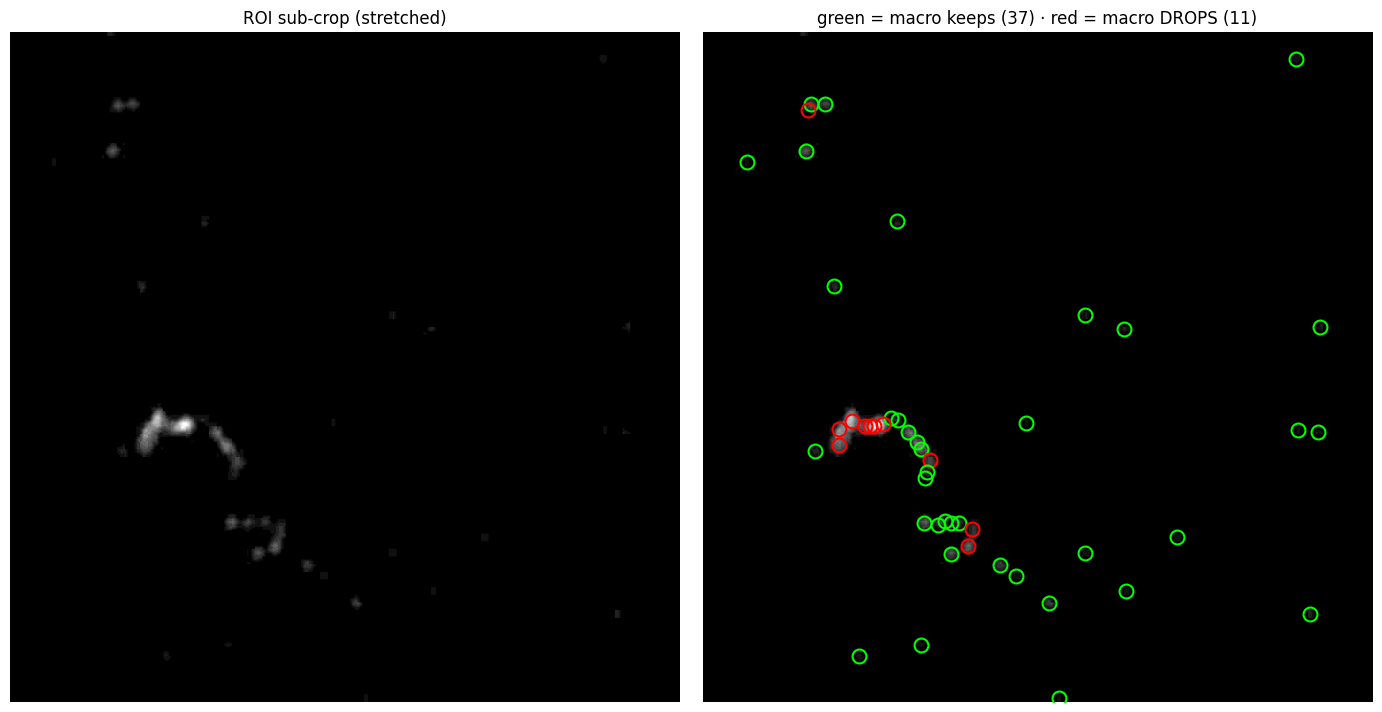

Red markers are real candidates the macro discards (mostly elongated/oblique or merged tracks).


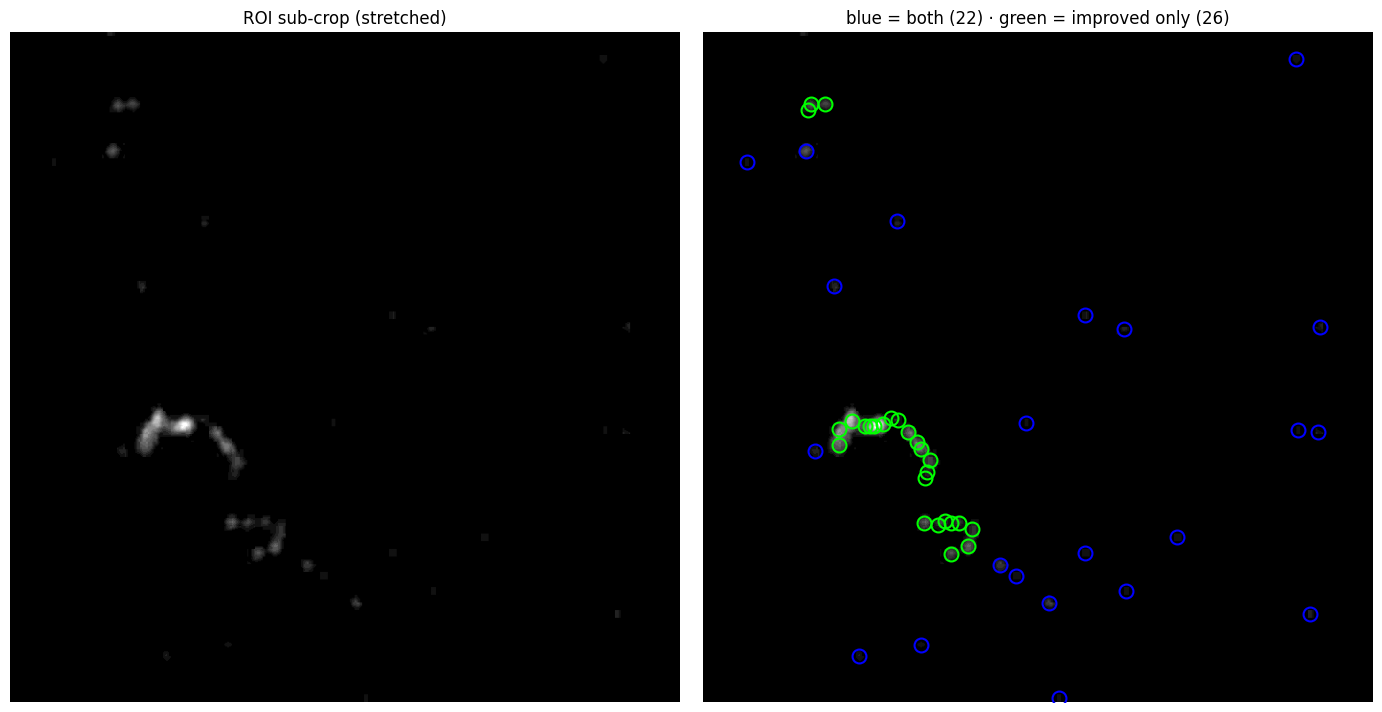

Macro detections in crop: 23  |  improved: 48  (match radius 12px)


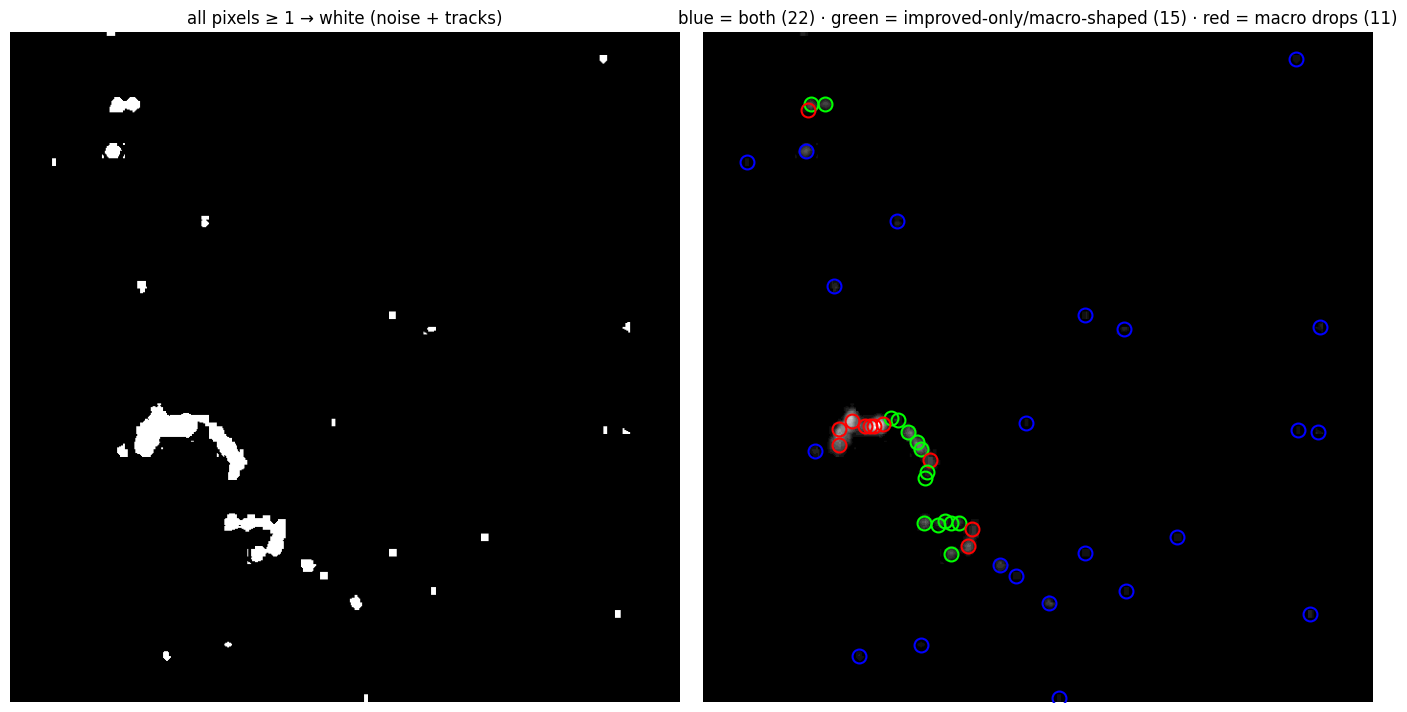

In [86]:
# What does the circularity filter actually throw away? Visualise on a dense sub-crop.
name = IMAGES[0].name
roi = load_roi(IMAGES[0])
labels, props = detect_cache[name]

# pick the densest 700x700 window for a legible close-up
step = 700
best, by, bx = -1, 0, 0
occ = labels > 0
for yy in range(0, roi.shape[0] - step, step):
    for xx in range(0, roi.shape[1] - step, step):
        s = occ[yy:yy+step, xx:xx+step].sum()
        if s > best: best, by, bx = s, yy, xx

sub = roi[by:by+step, bx:bx+step]
# Same window reused in Step 4 (compare NN vs improved on step1_overlay_three_color ROI)
STEP1_OVERLAY_ROI = dict(image=name, y0=int(by), x0=int(bx), size=int(step))
print(f"Step 1 overlay ROI → {STEP1_OVERLAY_ROI}  (saved for Step 4)")
stretch = np.clip(sub.astype(int) * 8, 0, 255)

# --- figure 1 (existing): green = macro keeps, red = macro drops (on improved detections) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(stretch, cmap="gray")
ax[0].set_title("ROI sub-crop (stretched)"); ax[0].axis("off")
ax[1].imshow(stretch, cmap="gray")

kept_round = dropped_elong = 0
for p in props:
    cy, cx = p.centroid
    if not (by <= cy < by+step and bx <= cx < bx+step):
        continue
    circ = _circularity(p.area, p.perimeter)
    is_macro_kept = (CFG.macro_size_min <= p.area <= CFG.macro_size_max) and \
                    (CFG.macro_circ_min <= circ <= CFG.macro_circ_max)
    color = "lime" if is_macro_kept else "red"
    kept_round += is_macro_kept; dropped_elong += (not is_macro_kept)
    ax[1].plot(cx - bx, cy - by, "o", mfc="none", mec=color, ms=10, mew=1.5)
ax[1].set_title(f"green = macro keeps ({kept_round}) · red = macro DROPS ({dropped_elong})")
ax[1].axis("off")
plt.tight_layout(); plt.savefig(CFG.out_dir / "step1_overlay.png", dpi=120); plt.show()
print("Red markers are real candidates the macro discards (mostly elongated/oblique or merged tracks).")

# --- figure 2: blue = both macro & improved, green = improved only ---
OVERLAY_MATCH_RADIUS = 12  # px in crop coords

def macro_centroids_crop(crop):
    lbl = measure.label(crop >= CFG.macro_thresh, connectivity=2)
    pts = []
    for p in measure.regionprops(lbl):
        if (CFG.macro_size_min <= p.area <= CFG.macro_size_max and
                CFG.macro_circ_min <= _circularity(p.area, p.perimeter) <= CFG.macro_circ_max):
            pts.append((p.centroid[1], p.centroid[0]))  # (x, y)
    return np.asarray(pts).reshape(-1, 2)

macro_pts = macro_centroids_crop(sub)
improved_in = []  # (x, y, is_macro_kept) in crop coordinates
for p in props:
    cy, cx = p.centroid
    if not (by <= cy < by + step and bx <= cx < bx + step):
        continue
    circ = _circularity(p.area, p.perimeter)
    is_macro_kept = (CFG.macro_size_min <= p.area <= CFG.macro_size_max) and \
                    (CFG.macro_circ_min <= circ <= CFG.macro_circ_max)
    improved_in.append((cx - bx, cy - by, is_macro_kept))

n_both = n_new_only = 0
fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
ax2[0].imshow(stretch, cmap="gray")
ax2[0].set_title("ROI sub-crop (stretched)"); ax2[0].axis("off")
ax2[1].imshow(stretch, cmap="gray")

for x, y, _ in improved_in:
    near_macro = False
    if len(macro_pts):
        d2 = (macro_pts[:, 0] - x) ** 2 + (macro_pts[:, 1] - y) ** 2
        near_macro = d2.min() <= OVERLAY_MATCH_RADIUS ** 2
    if near_macro:
        ax2[1].plot(x, y, "o", mfc="none", mec="blue", ms=10, mew=1.5)
        n_both += 1
    else:
        ax2[1].plot(x, y, "o", mfc="none", mec="lime", ms=10, mew=1.5)
        n_new_only += 1

ax2[1].set_title(f"blue = both ({n_both}) · green = improved only ({n_new_only})")
ax2[1].axis("off")
plt.tight_layout(); plt.savefig(CFG.out_dir / "step1_overlay_both_vs_new.png", dpi=120); plt.show()
print(f"Macro detections in crop: {len(macro_pts)}  |  improved: {len(improved_in)}  "
      f"(match radius {OVERLAY_MATCH_RADIUS}px)")

# --- figure 3: noise map (left) + improved with blue / green / red markers (right) ---
# blue  = near a macro detection (both methods agree on location)
# green = improved-only, macro-shaped (macro rules would keep, but no macro match nearby)
# red   = improved detection the macro would drop (elongated / merged / wrong size)
noise_view = np.where(sub >= 1, 255, 0).astype(np.uint8)
n_blue = n_green = n_red = 0
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 7))
ax3[0].imshow(noise_view, cmap="gray", vmin=0, vmax=255)
ax3[0].set_title("all pixels ≥ 1 → white (noise + tracks)"); ax3[0].axis("off")
ax3[1].imshow(stretch, cmap="gray")

for x, y, is_macro_kept in improved_in:
    near_macro = False
    if len(macro_pts):
        d2 = (macro_pts[:, 0] - x) ** 2 + (macro_pts[:, 1] - y) ** 2
        near_macro = d2.min() <= OVERLAY_MATCH_RADIUS ** 2
    if not is_macro_kept:
        color = "red"; n_red += 1
    elif near_macro:
        color = "blue"; n_blue += 1
    else:
        color = "lime"; n_green += 1
    ax3[1].plot(x, y, "o", mfc="none", mec=color, ms=10, mew=1.5)

ax3[1].set_title(f"blue = both ({n_blue}) · green = improved-only/macro-shaped ({n_green}) "
                 f"· red = macro drops ({n_red})")
ax3[1].axis("off")
plt.tight_layout(); plt.savefig(CFG.out_dir / "step1_overlay_three_color.png", dpi=120); plt.show()

## Step 2 — Cellpose-SAM baseline (pretrained, GPU/MPS)

[Cellpose](https://www.cellpose.org/) is a generalist instance-segmentation model built for exactly
this kind of blobby-object problem; v4 ("Cellpose-SAM") ships a single strong pretrained model and
**splits touching objects natively** — the macro's biggest blind spot.

We run it on a representative sub-crop first (fast, lets you eyeball quality), then optionally tile the
full ROI. No training, no labels. Tune `flow_threshold` / `cellprob_threshold` if it over/under-segments.

> Cellpose expects objects brighter than background (our case) and works best near its training scale,
> so we optionally upscale the small faint tracks with `CELLPOSE_UPSCALE`.

Cellpose model loaded (nuclei) on mps
Cellpose found 53 objects in the sub-crop in 35.8s


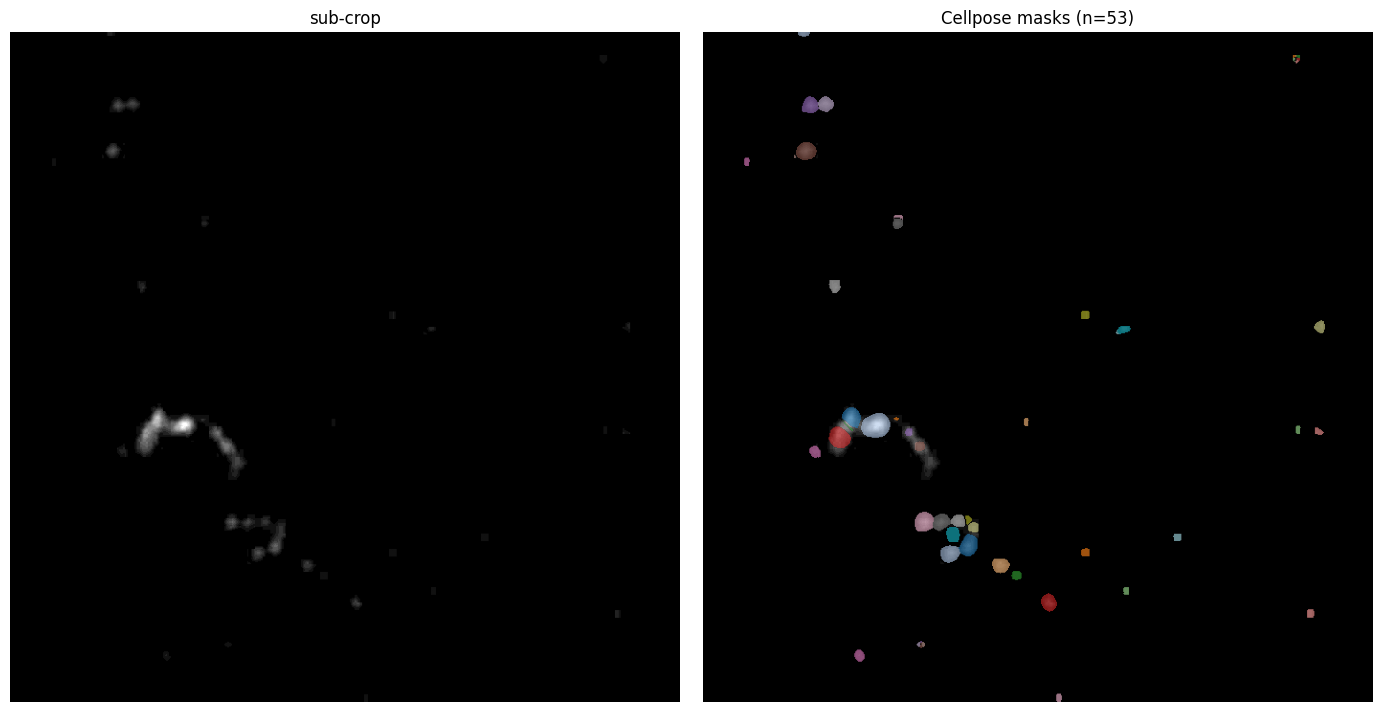

In [46]:
# Cellpose knobs
# CELLPOSE_UPSCALE = 2.0       # upscale faint small tracks toward Cellpose's comfort zone
# CELLPOSE_FLOW_THRESH = 0.4
# CELLPOSE_CELLPROB = 0.0
# CELLPOSE_STRETCH = 8         # contrast pre-stretch (tracks are very dim)
CELLPOSE_UPSCALE = 4.0       # upscale faint small tracks toward Cellpose's comfort zone
CELLPOSE_FLOW_THRESH = 0.99
CELLPOSE_CELLPROB = -3.0
CELLPOSE_STRETCH = 20         # contrast pre-stretch (tracks are very dim)

_cp_model = None
def get_cellpose():
    global _cp_model
    if _cp_model is None:
        from cellpose import models
        try:
            _cp_model = models.CellposeModel(gpu=True, device=DEVICE, model_type='nuclei')
        except TypeError:  # older signature
            _cp_model = models.CellposeModel(gpu=(DEVICE.type != "cpu"), model_type='nuclei')
        print("Cellpose model loaded (nuclei) on", DEVICE)
    return _cp_model

def cellpose_segment(gray_u8: np.ndarray, upscale=CELLPOSE_UPSCALE):
    """Return an integer mask (0=bg, 1..N objects) for a single-channel uint8 crop."""
    from skimage.transform import rescale
    img = np.clip(gray_u8.astype(np.float32) * CELLPOSE_STRETCH, 0, 255)
    if upscale and upscale != 1.0:
        img = rescale(img, upscale, order=1, preserve_range=True, anti_aliasing=True)
    model = get_cellpose()
    out = model.eval(img, batch_size=8, normalize=True,
                     flow_threshold=CELLPOSE_FLOW_THRESH,
                     cellprob_threshold=CELLPOSE_CELLPROB)
    masks = out[0]
    if upscale and upscale != 1.0:
        from skimage.transform import resize
        masks = resize(masks, gray_u8.shape, order=0, preserve_range=True,
                       anti_aliasing=False).astype(np.int32)
    return masks

# Run on the same dense sub-crop used in Step 1
t0 = time.time()
cp_masks = cellpose_segment(sub)
n_cp = int(cp_masks.max())
print(f"Cellpose found {n_cp} objects in the sub-crop in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(np.clip(sub.astype(int) * 8, 0, 255), cmap="gray"); ax[0].set_title("sub-crop"); ax[0].axis("off")
ax[1].imshow(np.clip(sub.astype(int) * 8, 0, 255), cmap="gray")
ax[1].imshow(np.ma.masked_where(cp_masks == 0, cp_masks % 20 + 1), cmap="tab20", alpha=0.6)
ax[1].set_title(f"Cellpose masks (n={n_cp})"); ax[1].axis("off")
plt.tight_layout(); plt.savefig(CFG.out_dir / "step2_cellpose_subcrop.png", dpi=120); plt.show()

In [47]:
# Apples-to-apples on the SAME sub-crop window: macro vs improved vs Cellpose
sub_macro = macro_count(sub)
_, sub_props = improved_detect(sub)
print(f"Sub-crop counts  ->  macro-style: {sub_macro}   improved: {len(sub_props)}   cellpose: {n_cp}")

# --- OPTIONAL: full-ROI Cellpose for every image via tiling (slow; flip the flag to enable) ---
RUN_CELLPOSE_FULL = False
TILE = 1024

def cellpose_count_full(roi, tile=TILE, overlap=64):
    total, H, W = 0, *roi.shape
    for yy in range(0, H, tile):
        for xx in range(0, W, tile):
            crop = roi[yy:min(yy+tile, H), xx:min(xx+tile, W)]
            if (crop > CFG.det_fixed_thresh).sum() == 0:
                continue
            m = cellpose_segment(crop, upscale=CELLPOSE_UPSCALE)
            total += int(m.max())
    return total

if RUN_CELLPOSE_FULL:
    cp_rows = []
    for path in IMAGES:
        t0 = time.time()
        c = cellpose_count_full(load_roi(path))
        cp_rows.append({"image": path.name, "cellpose_full": c})
        print(f"{path.name}: cellpose_full={c}  ({time.time()-t0:.0f}s)")
    cp_df = pd.DataFrame(cp_rows)
    base = base.merge(cp_df, on="image", how="left")
    base.to_csv(CFG.out_dir / "step1_counts.csv", index=False)
    display(base)
else:
    print("\nFull-ROI Cellpose disabled (set RUN_CELLPOSE_FULL=True to run; ~minutes/image on MPS).")

Sub-crop counts  ->  macro-style: 23   improved: 49   cellpose: 53

Full-ROI Cellpose disabled (set RUN_CELLPOSE_FULL=True to run; ~minutes/image on MPS).


## Step 3 — Unsupervised pipeline: autoencoder embeddings + clustering

The "smart, label-free" core:

1. **Candidates** from the Step-1 improved detector (high recall — includes tracks *and* artifacts).
2. Crop a fixed `patch_size×patch_size` window around each candidate centroid.
3. Train a small **convolutional autoencoder** (PyTorch, MPS) to reconstruct the patches → the bottleneck
   gives a `latent_dim`-D embedding per candidate. **No labels used.**
4. **Cluster** the embeddings (KMeans + GMM). Clusters self-organise into round tracks, elongated/oblique
   tracks, overlapping pairs, and dust/scratch artifacts.
5. **Label clusters, not objects:** inspect ~`n_clusters` montages once, tag artifact clusters, and get a
   cleaned per-image count — plus a physically meaningful track-type breakdown.

patch tensor: (14540, 48, 48)  (candidates across 15 images)


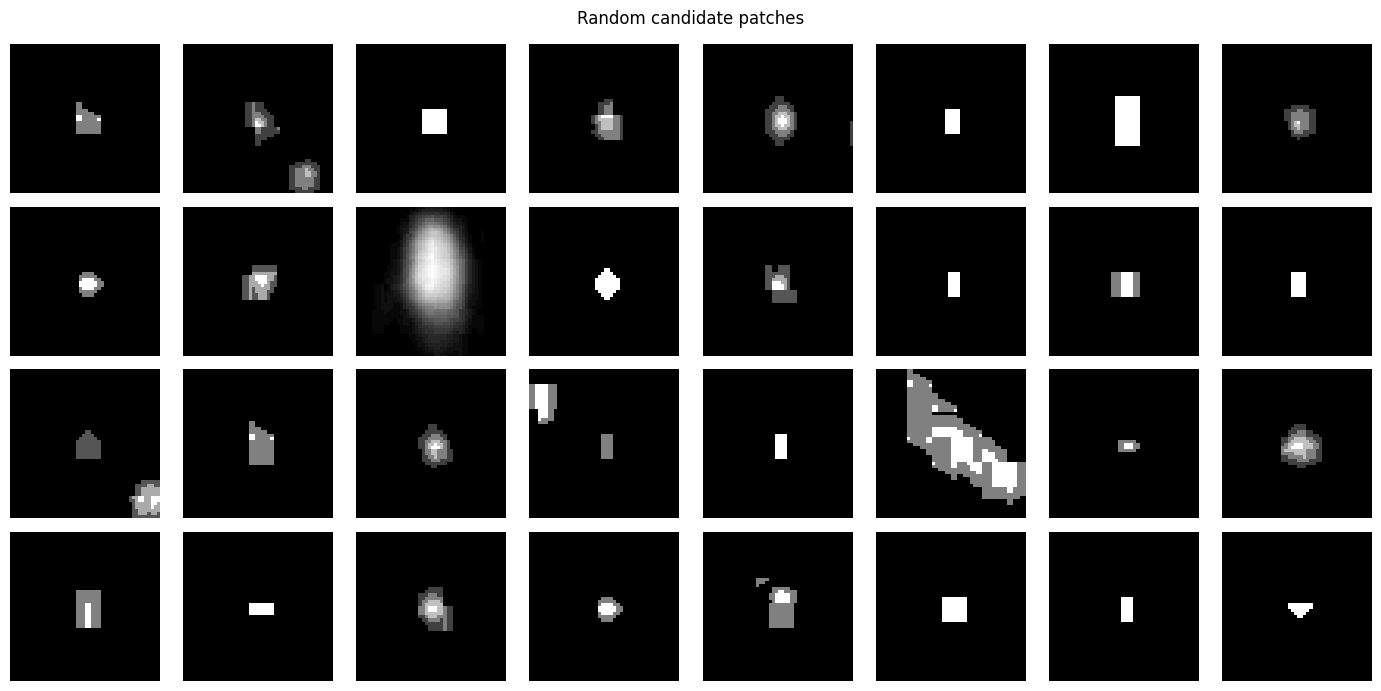

In [49]:
# 3.1 — Extract candidate patches from all images (reusing Step-1 detections)
P = CFG.patch_size
half = P // 2

patches, meta = [], []
for path in IMAGES:
    roi = load_roi(path)
    labels, props = detect_cache[path.name]
    Hh, Ww = roi.shape
    for p in props:
        cy, cx = map(int, p.centroid)
        y0, x0 = cy - half, cx - half
        if y0 < 0 or x0 < 0 or y0 + P > Hh or x0 + P > Ww:
            continue
        patches.append(roi[y0:y0+P, x0:x0+P])
        meta.append({
            "image": path.name, "cy": cy, "cx": cx,
            "area": p.area, "ecc": p.eccentricity,
            "major": p.axis_major_length, "minor": p.axis_minor_length,
            "circ": _circularity(p.area, p.perimeter),
            "mean_int": p.intensity_mean, "max_int": float(roi[y0:y0+P, x0:x0+P].max()),
        })

patches = np.stack(patches).astype(np.float32)
meta = pd.DataFrame(meta)

# subsample if over budget
if len(patches) > CFG.max_patches:
    idx = np.random.choice(len(patches), CFG.max_patches, replace=False)
    patches, meta = patches[idx], meta.iloc[idx].reset_index(drop=True)

# Per-patch contrast normalisation: divide each patch by its own peak so every track fills [0,1].
# This forces the autoencoder to encode track *shape/size* rather than collapsing to an all-black
# reconstruction (absolute brightness is kept separately as the `max_int` feature for clustering).
pmax = patches.reshape(len(patches), -1).max(axis=1)
pmax = np.clip(pmax, 1.0, None)
X = (patches / pmax[:, None, None]).astype(np.float32)
print(f"patch tensor: {X.shape}  (candidates across {meta['image'].nunique()} images)")

# preview a random grid of candidate patches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for ax, i in zip(axes.ravel(), np.random.choice(len(X), 32, replace=False)):
    ax.imshow(X[i], cmap="gray", vmin=0, vmax=1); ax.axis("off")
fig.suptitle("Random candidate patches"); plt.tight_layout(); plt.show()

In [51]:
# 3.2 — Convolutional autoencoder (PyTorch, MPS)
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(CFG.seed)

class ConvAE(nn.Module):
    def __init__(self, latent=CFG.latent_dim, p=CFG.patch_size):
        super().__init__()
        self.p = p
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(),      # p/2
            nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),     # p/4
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),     # p/8
        )
        self.feat = (p // 8)
        self.fc_enc = nn.Linear(64 * self.feat * self.feat, latent)
        self.fc_dec = nn.Linear(latent, 64 * self.feat * self.feat)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, 2, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_enc(h)

    def forward(self, x):
        z = self.encode(x)
        h = self.fc_dec(z).view(-1, 64, self.feat, self.feat)
        return self.dec(h), z

Xt = torch.from_numpy(X[:, None, :, :])  # (N,1,P,P)
loader = DataLoader(TensorDataset(Xt), batch_size=CFG.ae_batch, shuffle=True, drop_last=True)

model = ConvAE().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=CFG.ae_lr)
lossf = nn.MSELoss()
print(model)
print(f"trainable params: {sum(p.numel() for p in model.parameters()):,}")

ConvAE(
  (enc): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_enc): Linear(in_features=2304, out_features=32, bias=True)
  (fc_dec): Linear(in_features=32, out_features=2304, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)
trainable params: 214,353


epoch 01/25  recon MSE = 0.05774
epoch 02/25  recon MSE = 0.01125
epoch 03/25  recon MSE = 0.00884
epoch 04/25  recon MSE = 0.00732
epoch 05/25  recon MSE = 0.00614
epoch 06/25  recon MSE = 0.00472
epoch 07/25  recon MSE = 0.00416
epoch 08/25  recon MSE = 0.00387
epoch 09/25  recon MSE = 0.00358
epoch 10/25  recon MSE = 0.00334
epoch 11/25  recon MSE = 0.00309
epoch 12/25  recon MSE = 0.00287
epoch 13/25  recon MSE = 0.00262
epoch 14/25  recon MSE = 0.00248
epoch 15/25  recon MSE = 0.00239
epoch 16/25  recon MSE = 0.00230
epoch 17/25  recon MSE = 0.00222
epoch 18/25  recon MSE = 0.00215
epoch 19/25  recon MSE = 0.00209
epoch 20/25  recon MSE = 0.00204
epoch 21/25  recon MSE = 0.00199
epoch 22/25  recon MSE = 0.00193
epoch 23/25  recon MSE = 0.00191
epoch 24/25  recon MSE = 0.00187
epoch 25/25  recon MSE = 0.00180


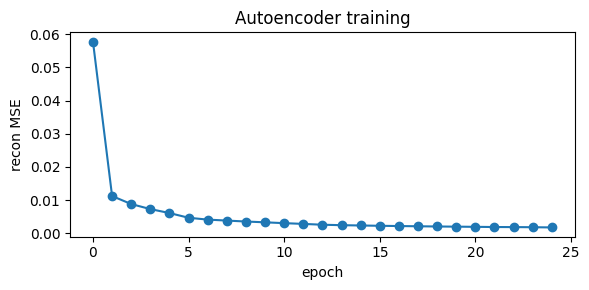

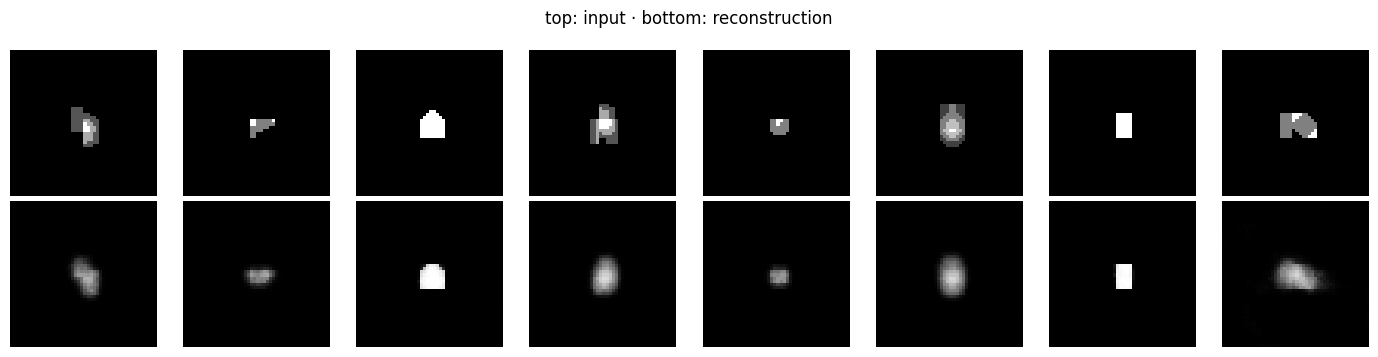

In [52]:
# 3.3 — Train the autoencoder
history = []
model.train()
for epoch in range(CFG.ae_epochs):
    running = 0.0
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        opt.zero_grad()
        xr, _ = model(xb)
        loss = lossf(xr, xb)
        loss.backward(); opt.step()
        running += loss.item() * xb.size(0)
    epoch_loss = running / (len(loader) * CFG.ae_batch)
    history.append(epoch_loss)
    print(f"epoch {epoch+1:02d}/{CFG.ae_epochs}  recon MSE = {epoch_loss:.5f}")

plt.figure(figsize=(6, 3))
plt.plot(history, marker="o"); plt.xlabel("epoch"); plt.ylabel("recon MSE")
plt.title("Autoencoder training"); plt.tight_layout(); plt.show()

# reconstruction sanity check
model.eval()
with torch.no_grad():
    sample = Xt[:8].to(DEVICE)
    rec, _ = model(sample)
rec = rec.cpu().numpy()
fig, axes = plt.subplots(2, 8, figsize=(14, 3.6))
for j in range(8):
    axes[0, j].imshow(X[j], cmap="gray", vmin=0, vmax=1); axes[0, j].axis("off")
    axes[1, j].imshow(rec[j, 0], cmap="gray", vmin=0, vmax=1); axes[1, j].axis("off")
axes[0, 0].set_ylabel("input"); axes[1, 0].set_ylabel("recon")
fig.suptitle("top: input · bottom: reconstruction"); plt.tight_layout(); plt.show()

In [53]:
# 3.4 — Compute embeddings for every candidate
model.eval()
embs = []
with torch.no_grad():
    for i in range(0, len(Xt), 512):
        z = model.encode(Xt[i:i+512].to(DEVICE))
        embs.append(z.cpu().numpy())
emb = np.concatenate(embs, 0)
print("embeddings:", emb.shape)

# Combine learned features with interpretable shape features. The two blocks have very different
# dimensionality (32 vs 6), so we standardise each block AND divide by sqrt(#dims) so neither
# dominates the Euclidean distance; `shape_weight` then lets morphology lead the clustering.
from sklearn.preprocessing import StandardScaler

shape_feats = meta[["area", "ecc", "circ", "major", "minor", "max_int"]].to_numpy(np.float32)
emb_s = StandardScaler().fit_transform(emb) / np.sqrt(emb.shape[1])
shp_s = StandardScaler().fit_transform(shape_feats) / np.sqrt(shape_feats.shape[1])

shape_weight = 2.0   # emphasise interpretable morphology over the raw AE code
Z = np.hstack([emb_s, shape_weight * shp_s])
np.save(CFG.out_dir / "embeddings.npy", emb)
print("combined feature matrix:", Z.shape)

embeddings: (14540, 32)
combined feature matrix: (14540, 38)


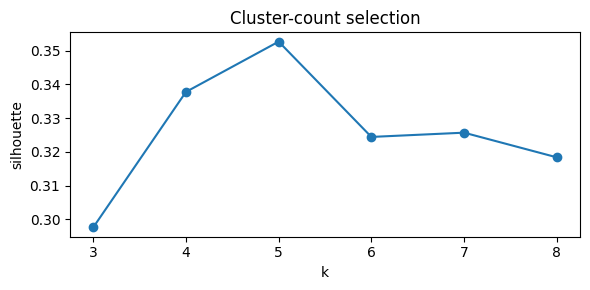

silhouette by k: {3: np.float64(0.298), 4: np.float64(0.338), 5: np.float64(0.353), 6: np.float64(0.324), 7: np.float64(0.326), 8: np.float64(0.318)}

cluster sizes:
cluster
0    4634
1    1902
2      13
3     257
4    4136
5    3598
Name: count, dtype: int64


In [89]:
# 3.5 — Choose k and cluster
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

ks = range(3, 9)
sil = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=CFG.seed).fit(Z)
    sil.append(silhouette_score(Z, km.labels_, sample_size=min(5000, len(Z)), random_state=CFG.seed))
plt.figure(figsize=(6, 3))
plt.plot(list(ks), sil, marker="o"); plt.xlabel("k"); plt.ylabel("silhouette")
plt.title("Cluster-count selection"); plt.tight_layout(); plt.show()
print("silhouette by k:", {k: round(s, 3) for k, s in zip(ks, sil)})

K = CFG.n_clusters
km = KMeans(n_clusters=K, n_init=10, random_state=CFG.seed).fit(Z)
meta["cluster"] = km.labels_
print("\ncluster sizes:")
print(meta["cluster"].value_counts().sort_index())

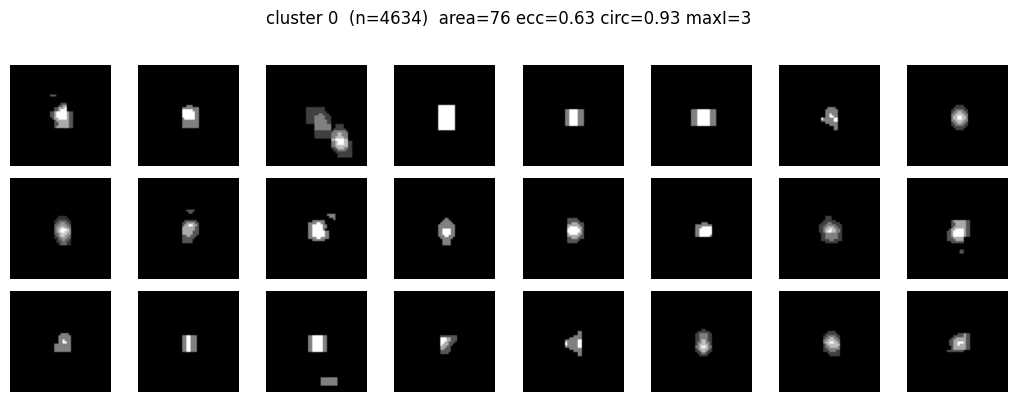

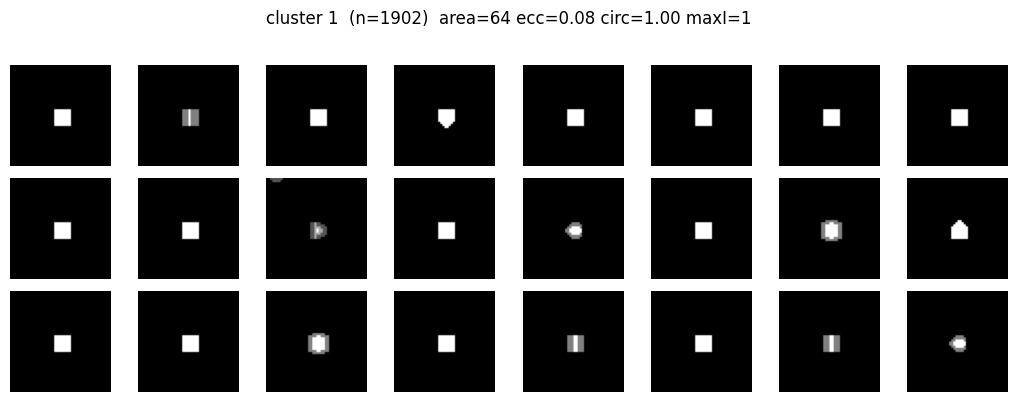

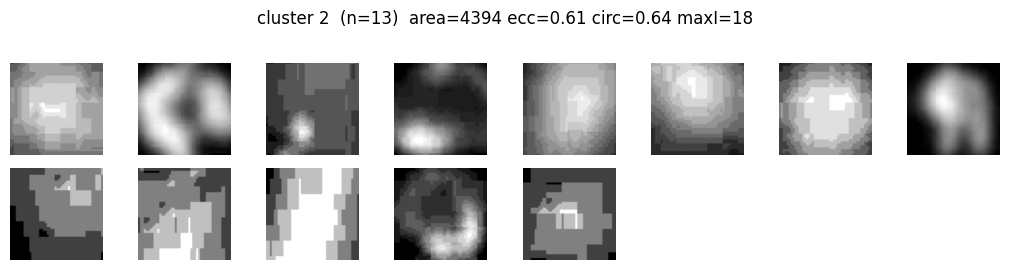

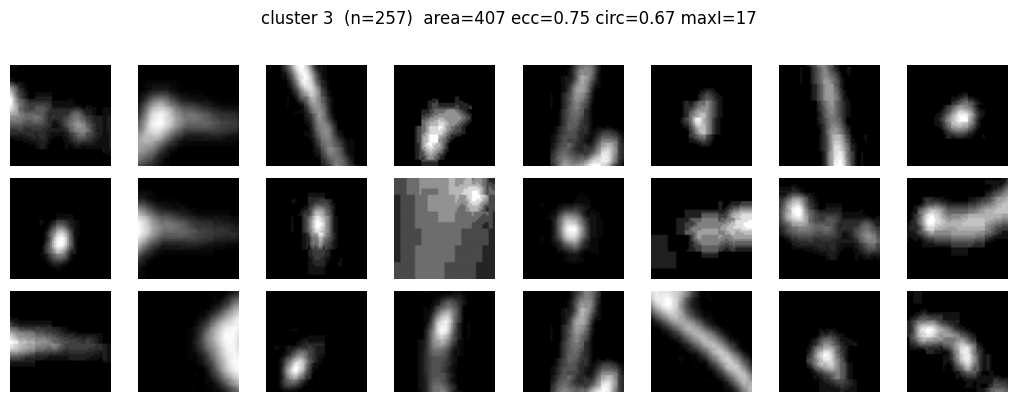

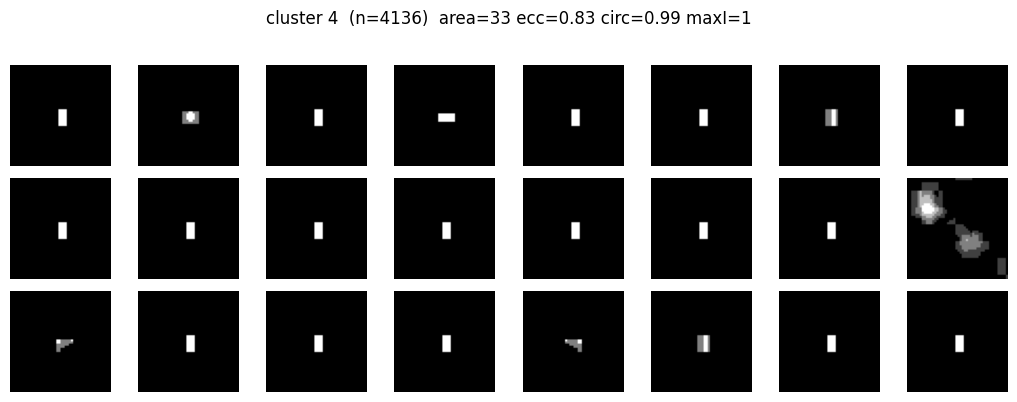

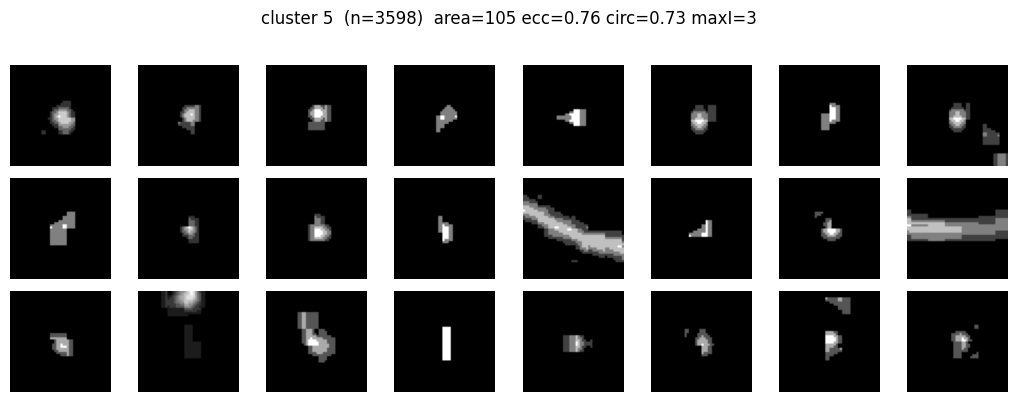

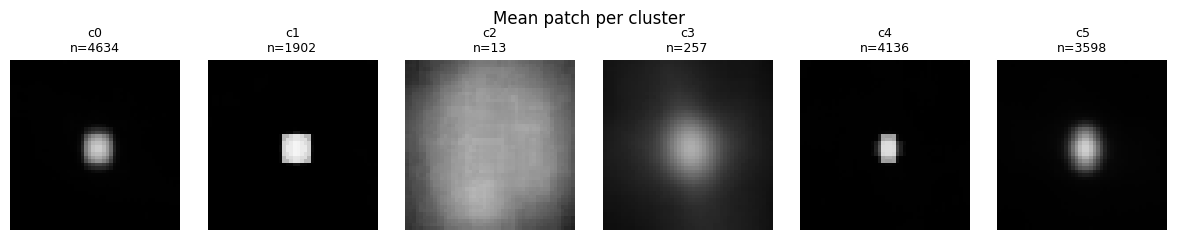

In [90]:
# 3.6 — Per-cluster montages + mean patch + shape profile (this is how you "label clusters, not objects")
def cluster_montage(c, n=24):
    idx = np.where(meta["cluster"].to_numpy() == c)[0]
    pick = np.random.choice(idx, min(n, len(idx)), replace=False)
    cols = 8; rows = int(np.ceil(len(pick) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.3))
    for ax in np.ravel(axes): ax.axis("off")
    for ax, i in zip(np.ravel(axes), pick):
        ax.imshow(X[i], cmap="gray", vmin=0, vmax=1)
    prof = meta.iloc[idx][["area", "ecc", "circ", "max_int"]].mean()
    fig.suptitle(f"cluster {c}  (n={len(idx)})  "
                 f"area={prof['area']:.0f} ecc={prof['ecc']:.2f} "
                 f"circ={prof['circ']:.2f} maxI={prof['max_int']:.0f}", y=1.02)
    plt.tight_layout(); plt.savefig(CFG.out_dir / f"cluster_{c}.png", dpi=110, bbox_inches="tight"); plt.show()

for c in range(K):
    cluster_montage(c)

# mean patch per cluster (a quick fingerprint)
fig, axes = plt.subplots(1, K, figsize=(2.0 * K, 2.4))
for c in range(K):
    idx = np.where(meta["cluster"].to_numpy() == c)[0]
    axes[c].imshow(X[idx].mean(0), cmap="gray", vmin=0, vmax=1)
    axes[c].set_title(f"c{c}\nn={len(idx)}", fontsize=9); axes[c].axis("off")
fig.suptitle("Mean patch per cluster"); plt.tight_layout(); plt.show()

### 3.6b — Real ROI with every cluster represented

Search all images for a **700×700** window that contains **at least one candidate from every cluster** (if possible). Mark every event in that window with the cluster colour.

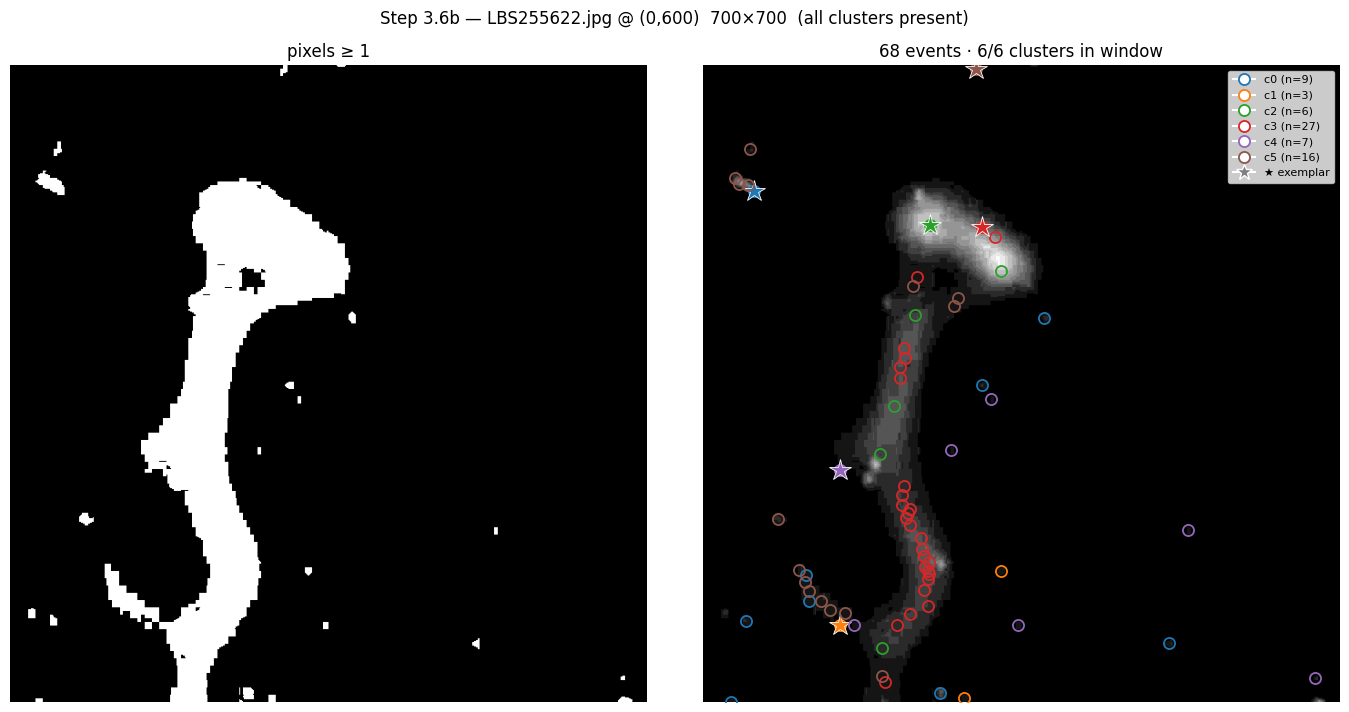

ROI: LBS255622.jpg  x0=0  y0=600  size=700
clusters in window: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]  (6/6)
Found a window with at least one event per cluster.
Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/algorithms/outputs/step3_all_clusters_roi.png


In [91]:
# 3.6b — Pick a 700×700 ROI with ≥1 event per cluster and plot markers
STEP36B_SIZE = 700
STEP36B_STRETCH = 8
STEP36B_GRID = 200

_cl_cmap = plt.cm.tab10
def _cl_color(cl):
    return _cl_cmap(int(cl) % 10)

def _cands_in_box(meta_df, image, x0, y0, size):
    m = ((meta_df["image"] == image) &
         (meta_df["cx"] >= x0) & (meta_df["cx"] < x0 + size) &
         (meta_df["cy"] >= y0) & (meta_df["cy"] < y0 + size))
    return meta_df.loc[m]

def _pick_roi_all_clusters(meta_df, size, grid, n_clusters):
    """Best window across all images: maximise distinct clusters, then candidate count."""
    best = None
    for path in IMAGES:
        roi = load_roi(path)
        name = path.name
        mimg = meta_df[meta_df["image"] == name]
        if mimg.empty:
            continue
        H, W = roi.shape
        for y0 in range(0, max(H - size, 1), grid):
            for x0 in range(0, max(W - size, 1), grid):
                sub = _cands_in_box(mimg, name, x0, y0, size)
                n_cl = int(sub["cluster"].nunique())
                score = (n_cl, len(sub))
                if best is None or score > best[0]:
                    best = (score, name, x0, y0, sub)
    return best

best = _pick_roi_all_clusters(meta, STEP36B_SIZE, STEP36B_GRID, K)
(n_cl, n_cand), img_name, x0, y0, cands = best
clusters_present = sorted(cands["cluster"].unique())
missing = [c for c in range(K) if c not in clusters_present]

roi = next(load_roi(p) for p in IMAGES if p.name == img_name)
crop = roi[y0:y0 + STEP36B_SIZE, x0:x0 + STEP36B_SIZE]
stretch = np.clip(crop.astype(int) * STEP36B_STRETCH, 0, 255)
noise = np.where(crop >= 1, 255, 0).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(noise, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("pixels ≥ 1"); ax[0].axis("off")

ax[1].imshow(stretch, cmap="gray")
for cl in clusters_present:
    col = _cl_color(cl)
    grp = cands[cands["cluster"] == cl]
    for _, r in grp.iterrows():
        ax[1].plot(r["cx"] - x0, r["cy"] - y0, "o", mfc="none", mec=col, ms=8, mew=1.3)

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker="o", color="w", markeredgecolor=_cl_color(cl),
                   markersize=8, mew=1.3, label=f"c{int(cl)} (n={int((cands['cluster']==cl).sum())})")
            for cl in clusters_present]
ax[1].legend(handles=legend, fontsize=8, loc="upper right")
ax[1].set_title(f"{len(cands)} events · {n_cl}/{K} clusters in window")
ax[1].axis("off")

status = "all clusters present" if not missing else f"missing clusters {missing}"
fig.suptitle(f"Step 3.6b — {img_name} @ ({x0},{y0})  {STEP36B_SIZE}×{STEP36B_SIZE}  ({status})",
             y=1.01)
plt.tight_layout()
plt.savefig(CFG.out_dir / "step3_all_clusters_roi.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"ROI: {img_name}  x0={x0}  y0={y0}  size={STEP36B_SIZE}")
print(f"clusters in window: {clusters_present}  ({n_cl}/{K})")
if missing:
    print(f"WARNING: no {STEP36B_SIZE}×{STEP36B_SIZE} window contains all {K} clusters — showing best match.")
else:
    print("Found a window with at least one event per cluster.")
print("Saved", CFG.out_dir / "step3_all_clusters_roi.png")

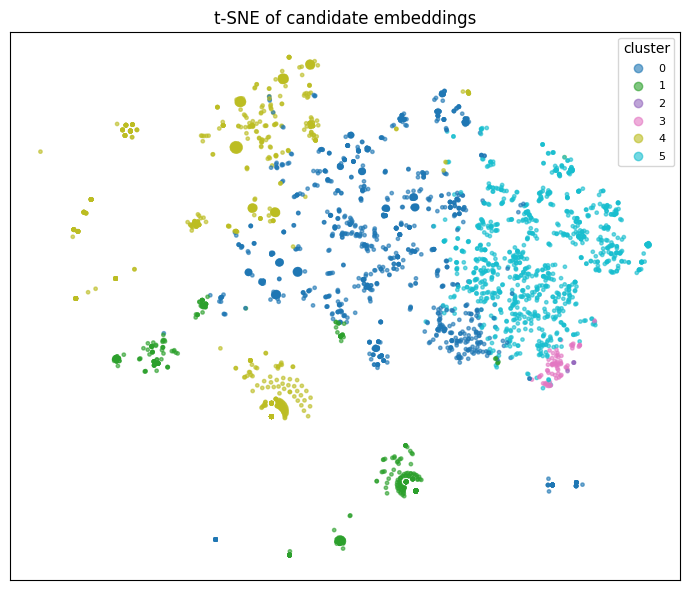

In [56]:
# 3.7 — 2D map of the embedding space (PCA -> t-SNE) coloured by cluster
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sub_n = min(4000, len(Z))
sidx = np.random.choice(len(Z), sub_n, replace=False)
Zp = PCA(n_components=min(30, Z.shape[1]), random_state=CFG.seed).fit_transform(Z[sidx])
emb2d = TSNE(n_components=2, perplexity=30, init="pca", random_state=CFG.seed).fit_transform(Zp)

plt.figure(figsize=(7, 6))
sc = plt.scatter(emb2d[:, 0], emb2d[:, 1], c=meta["cluster"].to_numpy()[sidx],
                 cmap="tab10", s=6, alpha=0.6)
plt.legend(*sc.legend_elements(), title="cluster", loc="best", fontsize=8)
plt.title("t-SNE of candidate embeddings"); plt.xticks([]); plt.yticks([])
plt.tight_layout(); plt.savefig(CFG.out_dir / "step3_tsne.png", dpi=120); plt.show()

,n,area,circ,ecc,max_int,saliency,suggest_artifact
cluster,,,,,,,
0,4634,76.069271,0.932866,0.634357,2.544454,193.554763,False
1,1902,63.900105,0.999093,0.075784,1.384858,88.492575,True
2,13,4394.000000,0.635553,0.610065,18.076923,79430.000000,False
3,257,407.038911,0.671798,0.749963,16.731518,6810.378658,False
4,4136,33.200677,0.989876,0.832837,1.458897,48.436384,True
5,3598,104.942190,0.733779,0.756920,3.006670,315.526574,False


Using ARTIFACT_CLUSTERS = [1, 4] (override manually)


,image,imagej_count,improved,nn_clean_count
0,LBS255611.jpg,795,1114,665
1,LBS255612.jpg,752,1044,586
2,LBS255613.jpg,729,954,542
3,LBS255614.jpg,713,916,471
4,LBS255615.jpg,719,906,498
5,LBS255616.jpg,640,783,422
6,LBS255617.jpg,810,1055,635
7,LBS255618.jpg,668,860,490
8,LBS255619.jpg,739,990,522
9,LBS255620.jpg,786,1068,665


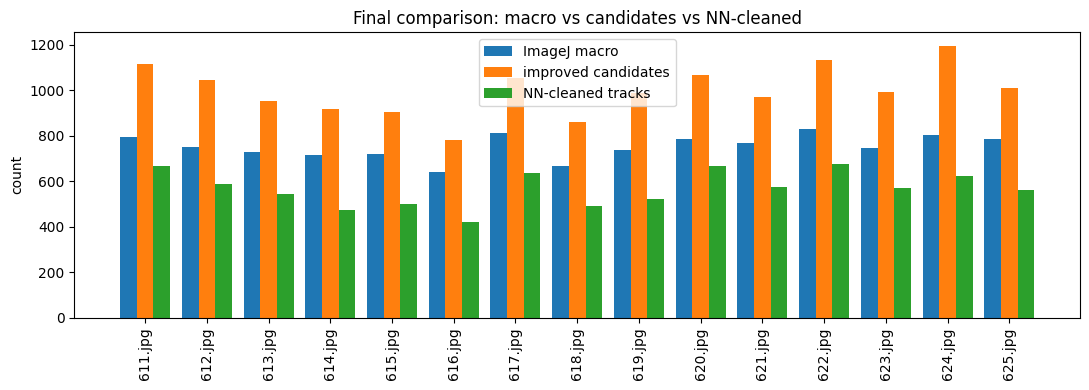

Saved final_counts.csv + candidates_labeled.csv in /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/algorithms/outputs


In [87]:
# 3.8 — Tag artifact clusters and produce a cleaned per-image count
#
# Inspect the montages above, then set ARTIFACT_CLUSTERS by hand. The heuristic below is only a
# starting suggestion: clusters whose patches are faint (low max intensity) and tiny are usually
# dust / JPEG speckle rather than genuine etched alpha tracks.
prof = meta.groupby("cluster").agg(
    n=("area", "size"), area=("area", "mean"),
    circ=("circ", "mean"), ecc=("ecc", "mean"), max_int=("max_int", "mean")
)
# Relative heuristic (data has dim tracks, so absolute cutoffs don't work): flag clusters that are
# simultaneously the faintest and smallest -> most likely dust / speckle rather than etched tracks.
sal = prof["area"] * prof["max_int"]   # crude "saliency": big & bright = more track-like
prof["saliency"] = sal
# conservative suggestion: only clusters that are clearly faint AND small (well below the median)
prof["suggest_artifact"] = sal < 0.5 * sal.median()
display(prof)

# ---- EDIT THIS after looking at the montages ----
ARTIFACT_CLUSTERS = prof.index[prof["suggest_artifact"]].tolist()
# ARTIFACT_CLUSTERS = [4]
print("Using ARTIFACT_CLUSTERS =", ARTIFACT_CLUSTERS, "(override manually)")

meta["is_track"] = ~meta["cluster"].isin(ARTIFACT_CLUSTERS)
meta.to_csv(CFG.out_dir / "candidates_labeled.csv", index=False)

clean = (meta[meta["is_track"]].groupby("image").size()
         .rename("nn_clean_count").reset_index())
final = base.merge(clean, on="image", how="left").fillna({"nn_clean_count": 0})
final["nn_clean_count"] = final["nn_clean_count"].astype(int)

# track-type breakdown per image (real-track clusters only)
breakdown = (meta[meta["is_track"]]
             .pivot_table(index="image", columns="cluster", values="area", aggfunc="size", fill_value=0))
breakdown.columns = [f"cluster_{c}" for c in breakdown.columns]
final = final.merge(breakdown.reset_index(), on="image", how="left")
final.to_csv(CFG.out_dir / "final_counts.csv", index=False)
display(final[["image", "imagej_count", "improved", "nn_clean_count"]])

x = np.arange(len(final)); w = 0.27
plt.figure(figsize=(11, 4))
plt.bar(x - w, final["imagej_count"], w, label="ImageJ macro")
plt.bar(x,      final["improved"],     w, label="improved candidates")
plt.bar(x + w,  final["nn_clean_count"], w, label="NN-cleaned tracks")
plt.xticks(x, [n[-7:] for n in final["image"]], rotation=90)
plt.ylabel("count"); plt.legend(); plt.title("Final comparison: macro vs candidates vs NN-cleaned")
plt.tight_layout(); plt.savefig(CFG.out_dir / "final_counts.png", dpi=120); plt.show()
print("Saved final_counts.csv + candidates_labeled.csv in", CFG.out_dir)

### 3.9 — Cluster-coloured ROI overlays

Same stretched ROI views as Step 1, but every improved candidate is marked with the **cluster colour** from Step 3 (tab10 palette, matching t-SNE / montages). Artifact clusters are noted in the legend.

Windows plotted:
1. **Step 1 overlay ROI** — identical `(x0, y0, size)` as `step1_overlay_three_color.png` → `step3_step1_three_color_clusters.png`
2. **dense** — most candidates in a 700×700 window
3. **max_disagreement** — most candidates dropped by `ARTIFACT_CLUSTERS`
4. **cluster_rich** — most distinct clusters represented in one window

step1 ROI: LBS255611.jpg  x0=700 y0=1400 size=700


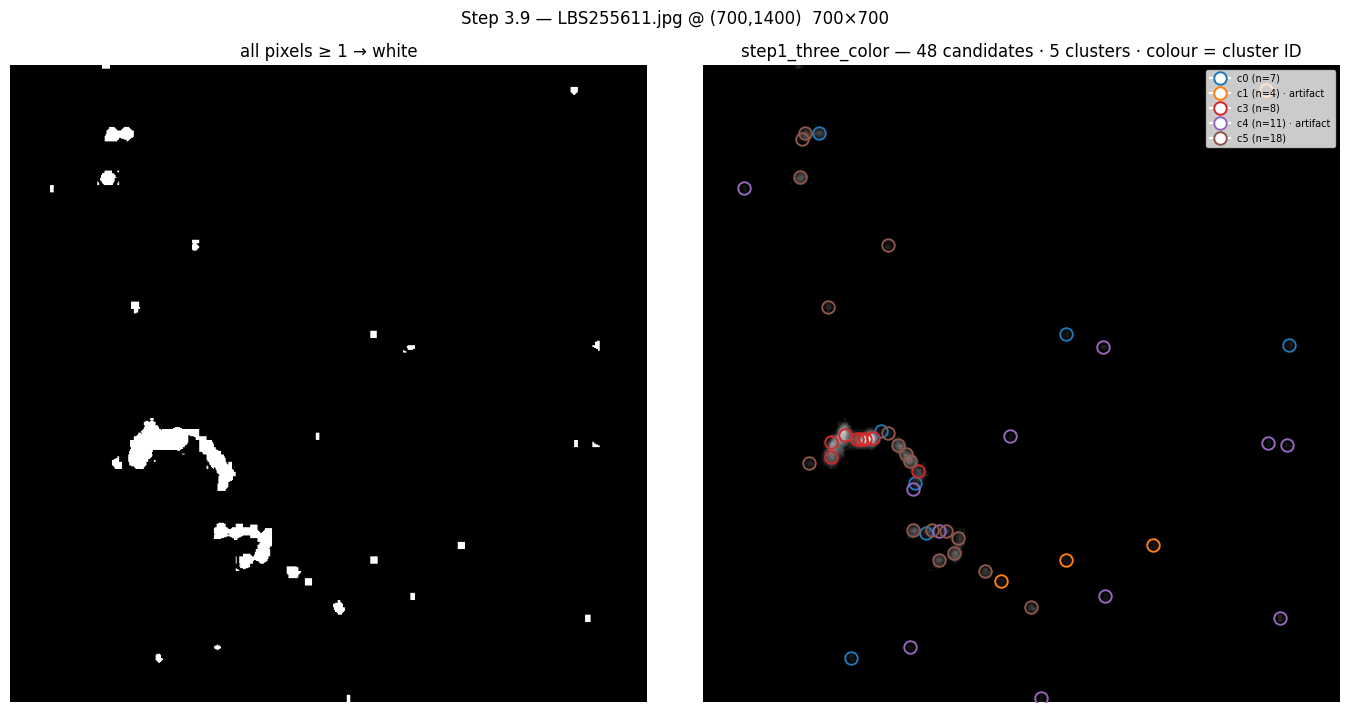

dense: LBS255611.jpg  x0=400 y0=2800


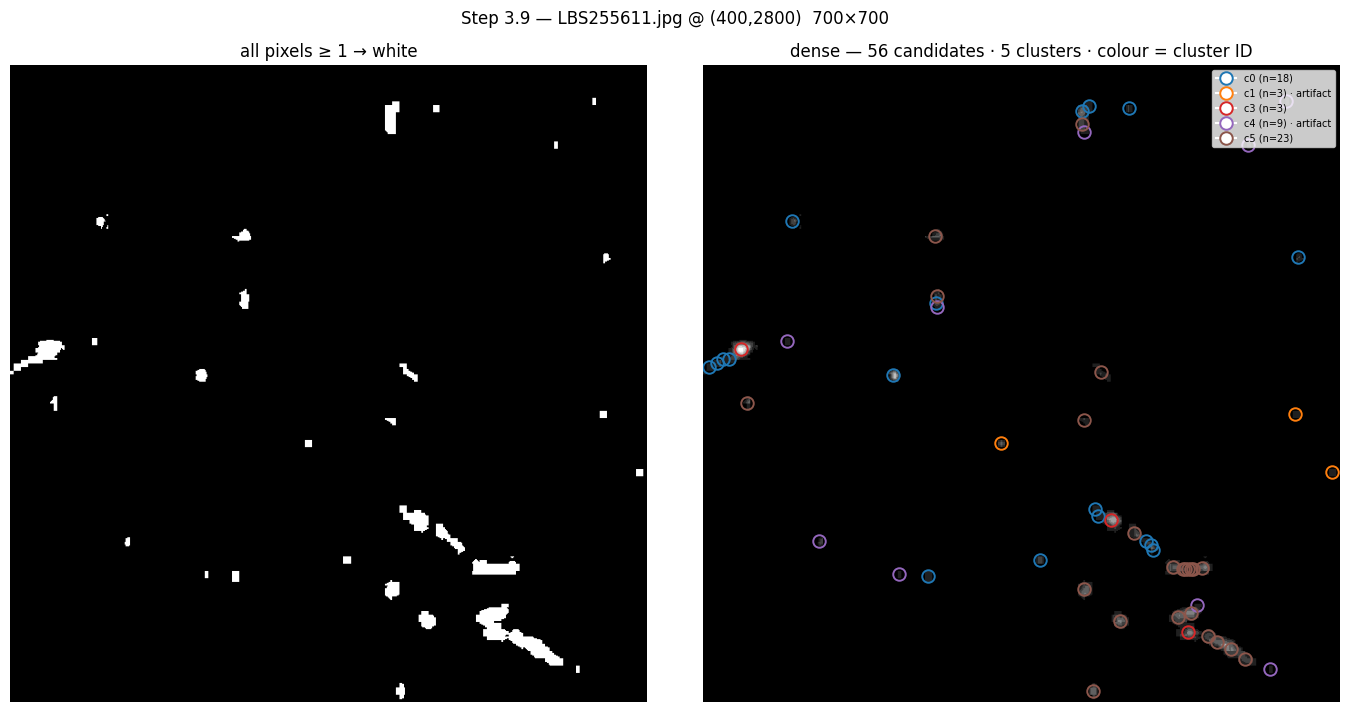

max_disagreement: LBS255611.jpg  x0=2800 y0=200


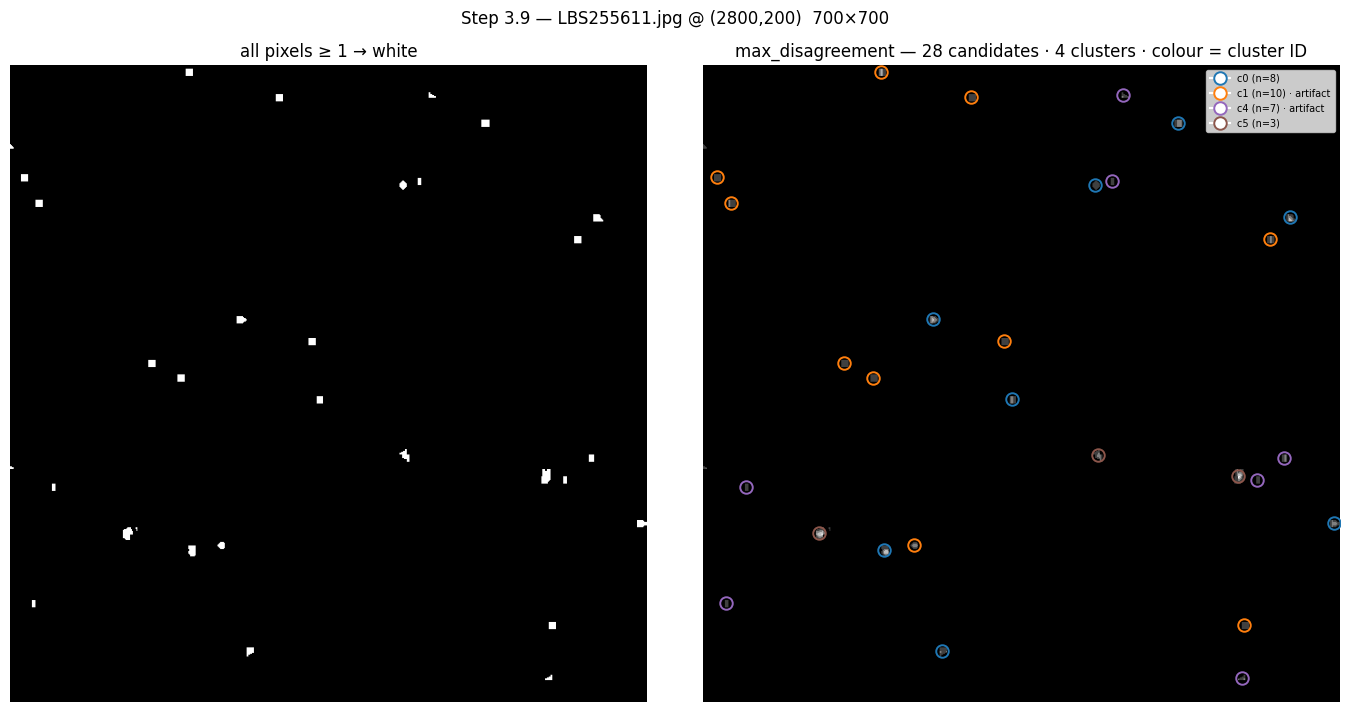

cluster_rich: LBS255611.jpg  x0=400 y0=2800


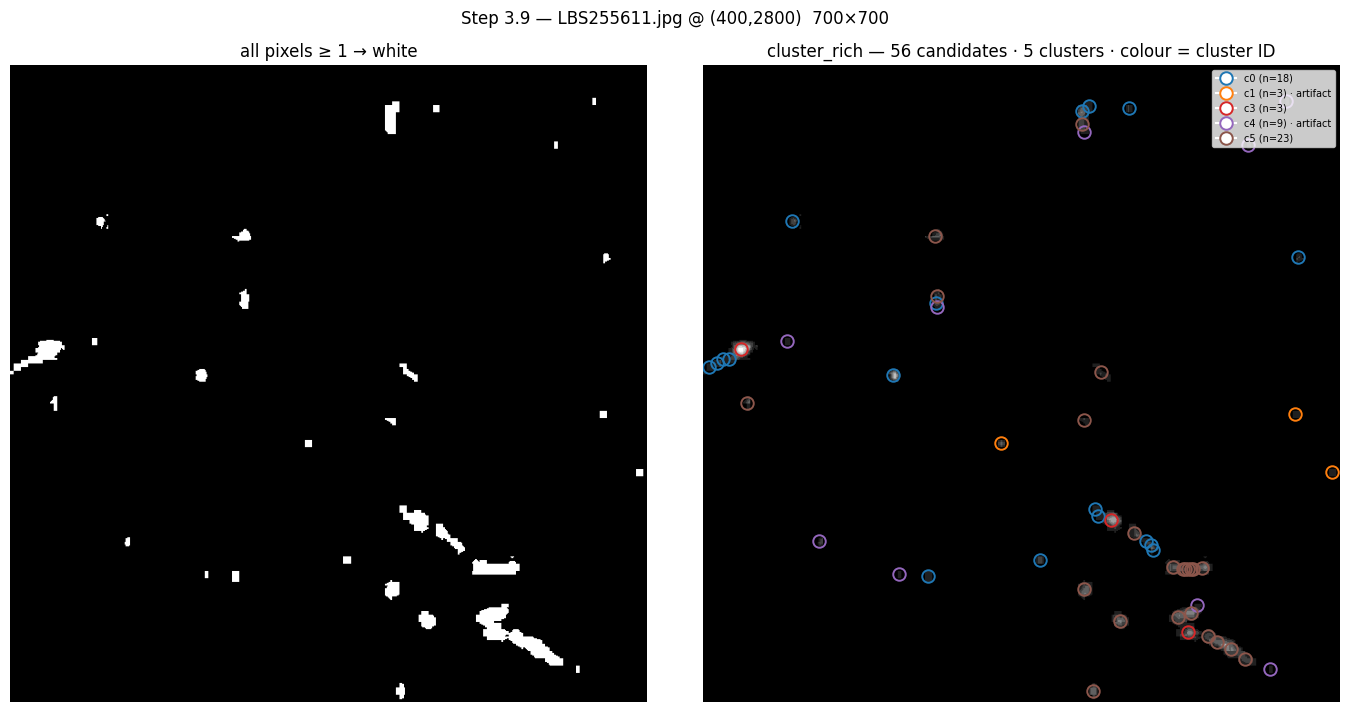

,image,roi_tag,x0,y0,size,n_candidates,n_clusters,cluster_0,cluster_1,cluster_3,cluster_4,cluster_5
0,LBS255611.jpg,step1_three_color,700,1400,700,48,5,7,4,8.0,11,18
1,LBS255611.jpg,dense,400,2800,700,56,5,18,3,3.0,9,23
2,LBS255611.jpg,max_disagreement,2800,200,700,28,4,8,10,NaN,7,3
3,LBS255611.jpg,cluster_rich,400,2800,700,56,5,18,3,3.0,9,23


Saved step3_*_clusters.png + step3_cluster_roi_summary.csv


In [88]:
# 3.9 — Cluster-coloured overlays on ROI windows
STEP39_SIZE = 700
STEP39_STRETCH = 8
STEP39_GRID = 200

_CLUSTER_CMAP = plt.cm.tab10

def _cluster_color(cl):
    return _CLUSTER_CMAP(int(cl) % 10)

def _cluster_legend_handles(cands_df, artifact_clusters=None):
    from matplotlib.lines import Line2D
    artifact_clusters = set(artifact_clusters or [])
    handles = []
    for cl in sorted(cands_df["cluster"].unique()):
        n = int((cands_df["cluster"] == cl).sum())
        tag = " · artifact" if cl in artifact_clusters else ""
        handles.append(Line2D([0], [0], marker="o", color="w",
                              markeredgecolor=_cluster_color(cl), markersize=9, mew=1.4,
                              label=f"c{int(cl)} (n={n}){tag}"))
    return handles

def _step39_cands_in_window(meta_df, image, x0, y0, size):
    m = ((meta_df["image"] == image) &
         (meta_df["cx"] >= x0) & (meta_df["cx"] < x0 + size) &
         (meta_df["cy"] >= y0) & (meta_df["cy"] < y0 + size))
    return meta_df.loc[m].copy()

def _step39_get_step1_roi():
    if "STEP1_OVERLAY_ROI" in globals() and STEP1_OVERLAY_ROI:
        return STEP1_OVERLAY_ROI
    name = IMAGES[0].name
    roi0 = load_roi(IMAGES[0])
    labels0, _ = detect_cache[name]
    step = STEP39_SIZE
    best, by, bx = -1, 0, 0
    occ = labels0 > 0
    for yy in range(0, roi0.shape[0] - step, step):
        for xx in range(0, roi0.shape[1] - step, step):
            s = int(occ[yy:yy + step, xx:xx + step].sum())
            if s > best:
                best, by, bx = s, yy, xx
    print("Note: STEP1_OVERLAY_ROI not found — recomputed from Step-1 overlay logic.")
    return dict(image=name, y0=int(by), x0=int(bx), size=int(step))

def _step39_load_roi(image_name):
    for p in IMAGES:
        if p.name == image_name:
            return load_roi(p)
    raise ValueError(f"image not in IMAGES: {image_name}")

def _pick_step39_roi(meta_df, image_name, roi_h, roi_w, size, mode="dense"):
    """Return (x0, y0, tag) for a STEP39_SIZE window."""
    best = None
    for y0 in range(0, roi_h - size, STEP39_GRID):
        for x0 in range(0, roi_w - size, STEP39_GRID):
            sub = _step39_cands_in_window(meta_df, image_name, x0, y0, size)
            n = len(sub)
            n_cl = int(sub["cluster"].nunique()) if n else 0
            n_drop = int((~sub["is_track"]).sum()) if n else 0
            if mode == "dense":
                score = n
            elif mode == "max_disagreement":
                score = n_drop
            elif mode == "cluster_rich":
                score = (n_cl, n)
            else:
                raise ValueError(f"unknown mode: {mode}")
            if best is None or score > best[0]:
                best = (score, x0, y0)
    tag = mode
    return best[1], best[2], tag

def plot_cluster_overlay(image_name, roi, meta_df, x0, y0, size, tag, save=True):
    crop = roi[y0:y0 + size, x0:x0 + size]
    stretch = np.clip(crop.astype(int) * STEP39_STRETCH, 0, 255)
    noise = np.where(crop >= 1, 255, 0).astype(np.uint8)
    cands = _step39_cands_in_window(meta_df, image_name, x0, y0, size)

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(noise, cmap="gray", vmin=0, vmax=255)
    ax[0].set_title("all pixels ≥ 1 → white"); ax[0].axis("off")
    ax[1].imshow(stretch, cmap="gray")
    for cl in sorted(cands["cluster"].unique()):
        col = _cluster_color(cl)
        grp = cands[cands["cluster"] == cl]
        for _, r in grp.iterrows():
            ax[1].plot(r["cx"] - x0, r["cy"] - y0, "o", mfc="none", mec=col, ms=9, mew=1.4)
    n_cl = int(cands["cluster"].nunique()) if len(cands) else 0
    ax[1].set_title(f"{tag} — {len(cands)} candidates · {n_cl} clusters · colour = cluster ID")
    if len(cands):
        ax[1].legend(handles=_cluster_legend_handles(cands, ARTIFACT_CLUSTERS),
                     fontsize=7, loc="upper right")
    ax[1].axis("off")
    fig.suptitle(f"Step 3.9 — {image_name} @ ({x0},{y0})  {size}×{size}", y=1.01)
    plt.tight_layout()
    if save:
        fig.savefig(CFG.out_dir / f"step3_{tag}_clusters.png", dpi=120, bbox_inches="tight")
    plt.show()

    by_cl = cands.groupby("cluster").size().to_dict() if len(cands) else {}
    return {
        "image": image_name, "roi_tag": tag, "x0": x0, "y0": y0, "size": size,
        "n_candidates": len(cands), "n_clusters": n_cl,
        **{f"cluster_{int(k)}": int(v) for k, v in by_cl.items()},
    }

# --- run overlays ---
step39_rows = []

s1 = _step39_get_step1_roi()
print(f"step1 ROI: {s1['image']}  x0={s1['x0']} y0={s1['y0']} size={s1['size']}")
step39_rows.append(plot_cluster_overlay(
    s1["image"], _step39_load_roi(s1["image"]), meta,
    s1["x0"], s1["y0"], s1["size"], "step1_three_color"))

img_name = s1["image"]
roi = _step39_load_roi(img_name)
_m = meta[meta["image"] == img_name]

for mode in ("dense", "max_disagreement", "cluster_rich"):
    x0, y0, tag = _pick_step39_roi(_m, img_name, CFG.roi_h, CFG.roi_w, STEP39_SIZE, mode=mode)
    print(f"{tag}: {img_name}  x0={x0} y0={y0}")
    step39_rows.append(plot_cluster_overlay(img_name, roi, meta, x0, y0, STEP39_SIZE, tag))

step39_df = pd.DataFrame(step39_rows)
step39_df.to_csv(CFG.out_dir / "step3_cluster_roi_summary.csv", index=False)
display(step39_df)
print("Saved step3_*_clusters.png + step3_cluster_roi_summary.csv")

## Step 4 — Confront Step 3 (NN-clean) vs improved macro (same ROI)

Step 3 filters improved candidates by cluster (`ARTIFACT_CLUSTERS` → `is_track`).
This step **visualises where the two methods agree or disagree** on the **same ROI windows**:

- **Step 1 three-color ROI** — *exact same* 700×700 window as `step1_overlay_three_color.png`
  (coordinates saved in `STEP1_OVERLAY_ROI` when you run Step 1).
- **Dense ROI** — most candidates (finer grid search).
- **Max-disagreement ROI** — window where Step 3 drops the most improved detections.

For each ROI we report counts (ImageJ macro / improved / NN-clean), a **blue vs red**
disagreement overlay, a **waterfall** of NN drops by cluster, and a **morphology scatter**
(area vs eccentricity: kept vs dropped).

Outputs → `algorithms/outputs/step4_*.png` and `step4_roi_comparison.csv`.

Note: STEP1_OVERLAY_ROI not found — recomputed from Step-1 overlay logic.
step1_three_color ROI: LBS255611.jpg  x0=700 y0=1400 size=700


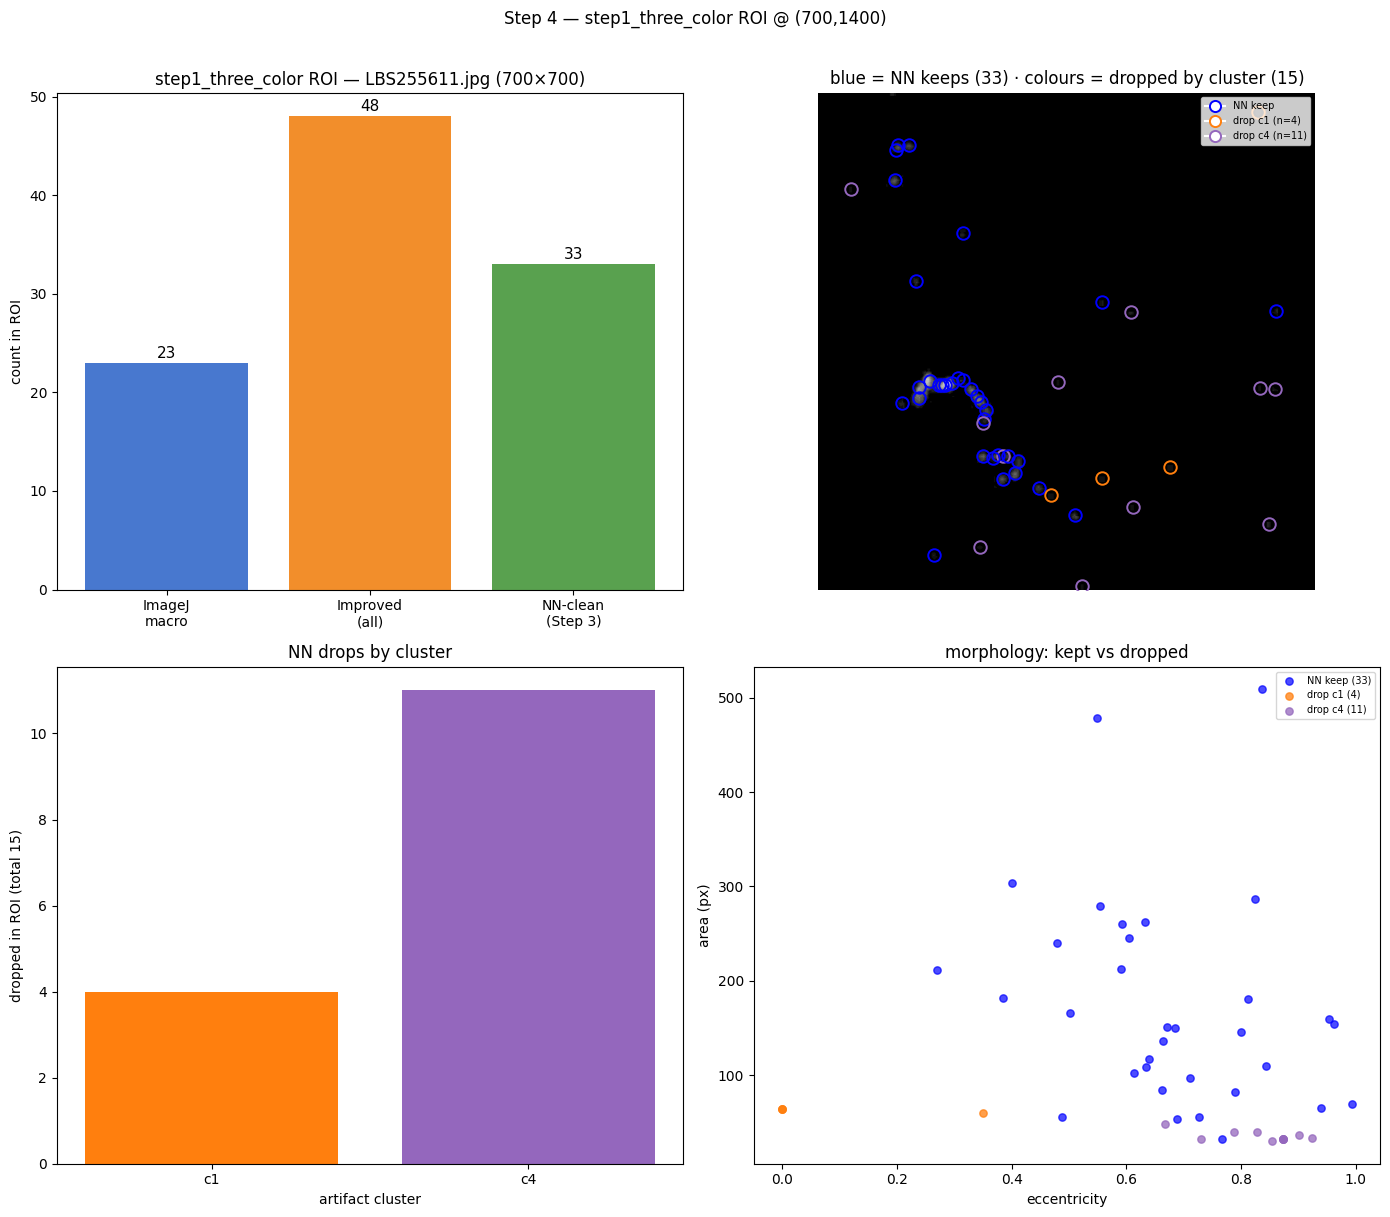

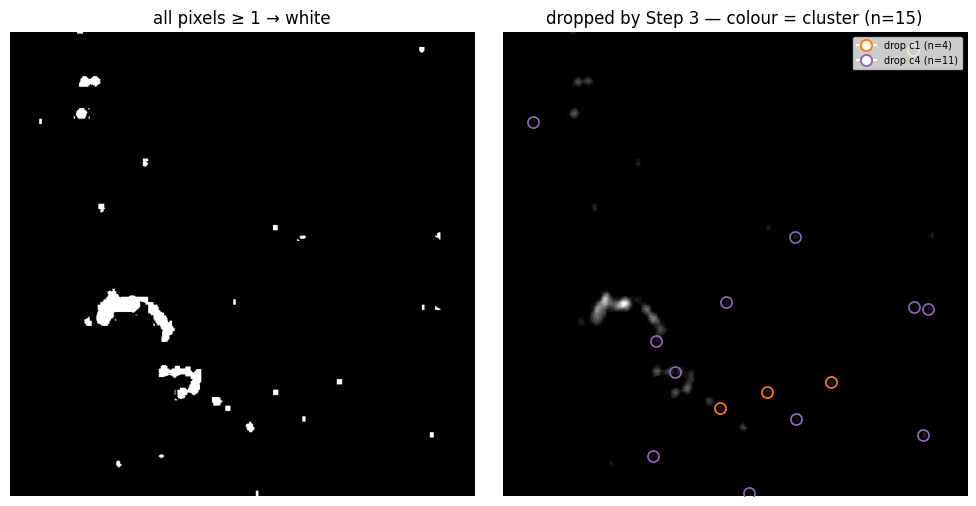

dense: LBS255611.jpg  x0=400 y0=2800  (score window)


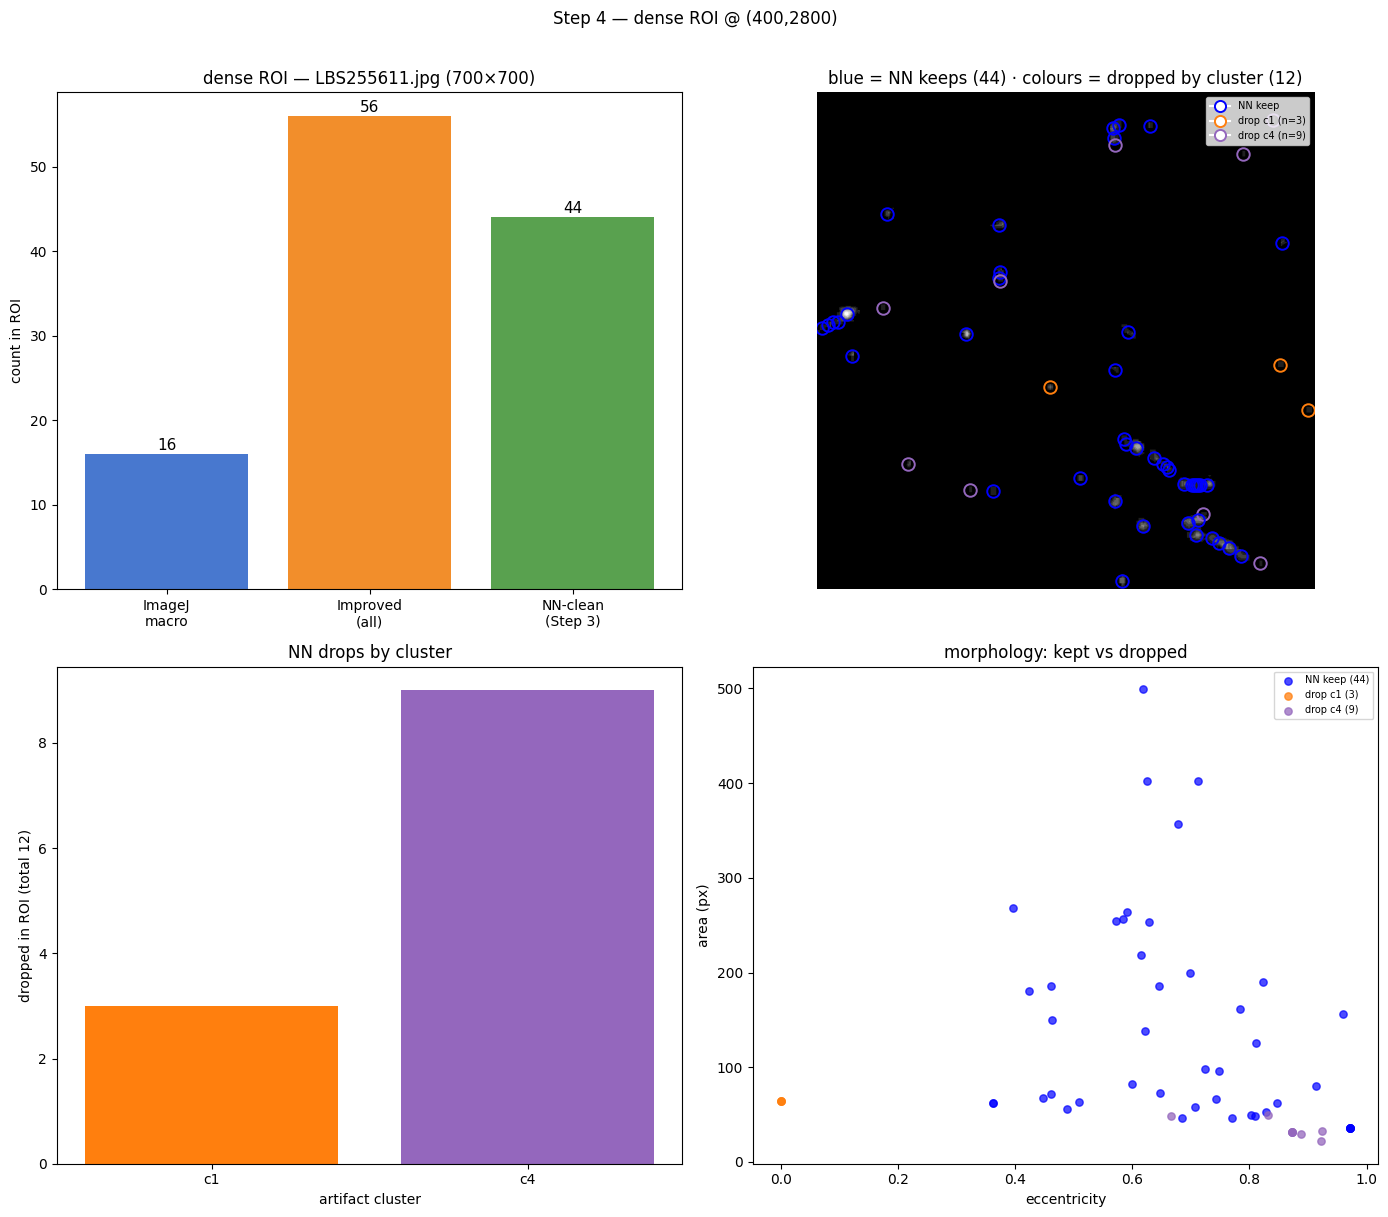

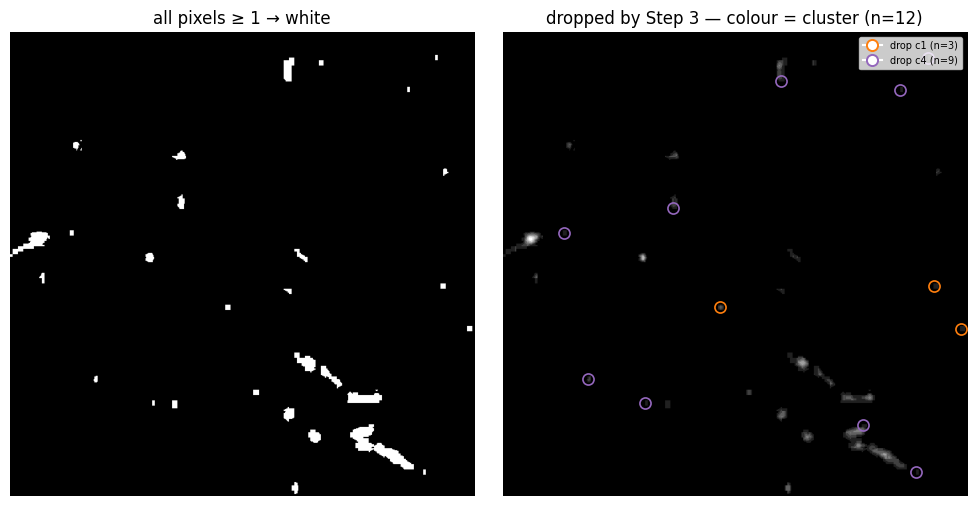

max_disagreement: LBS255611.jpg  x0=2800 y0=200  (score window)


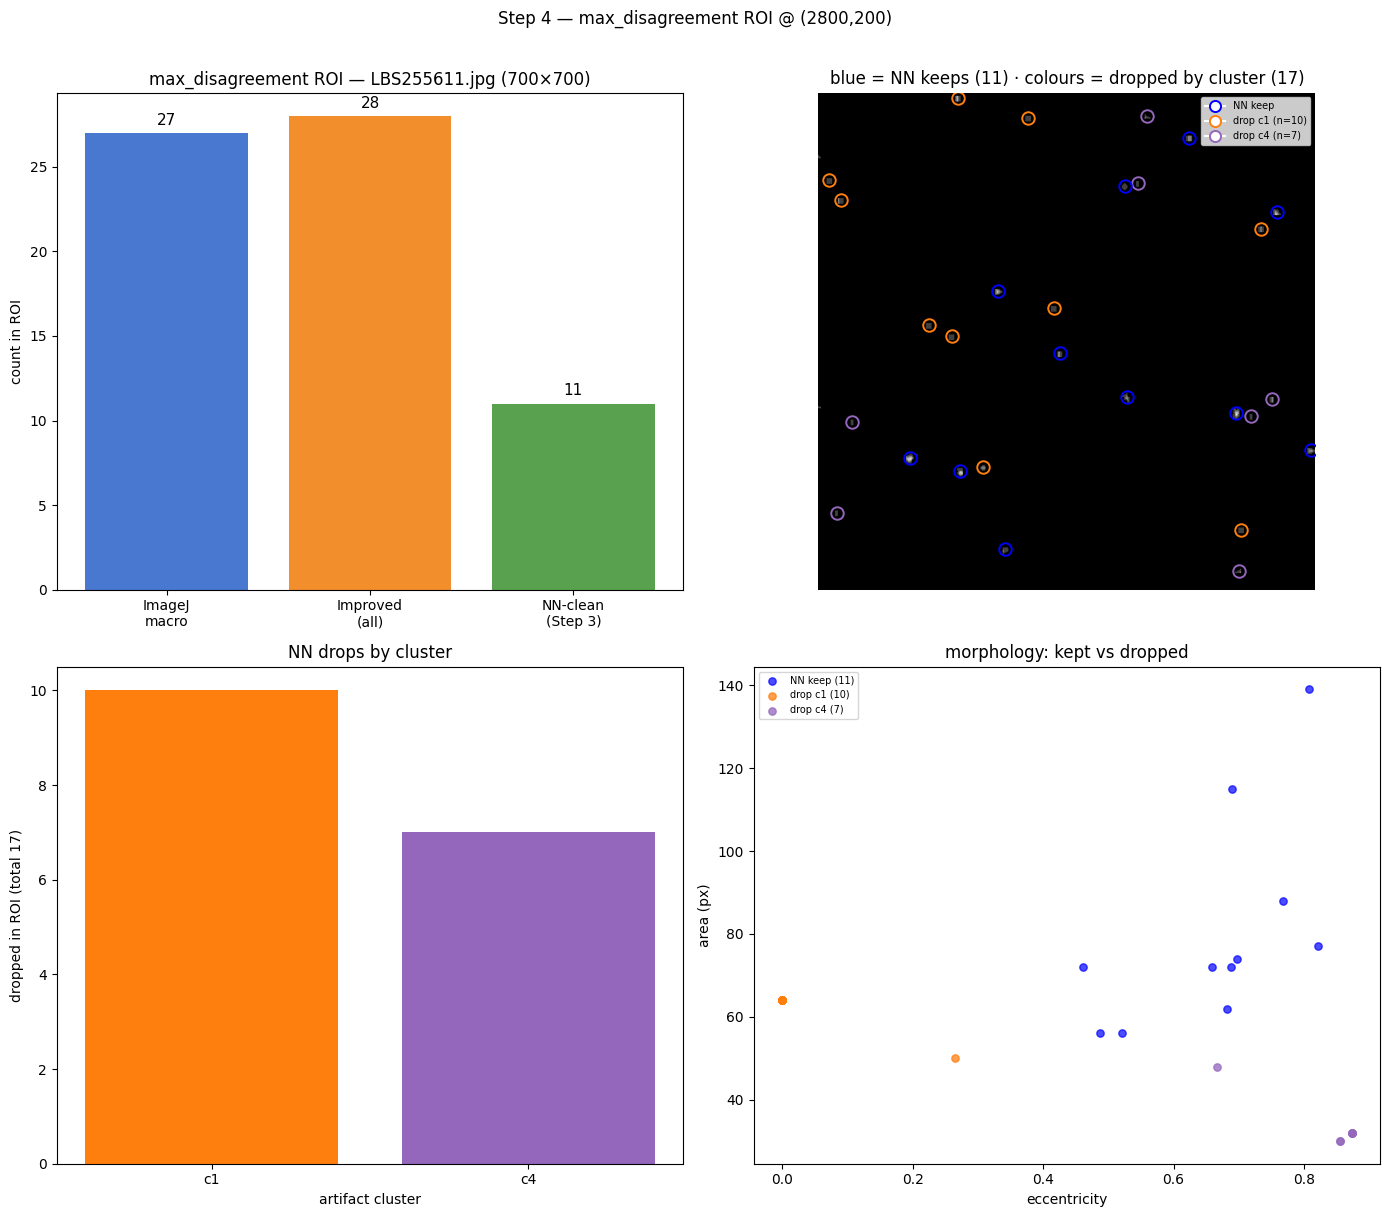

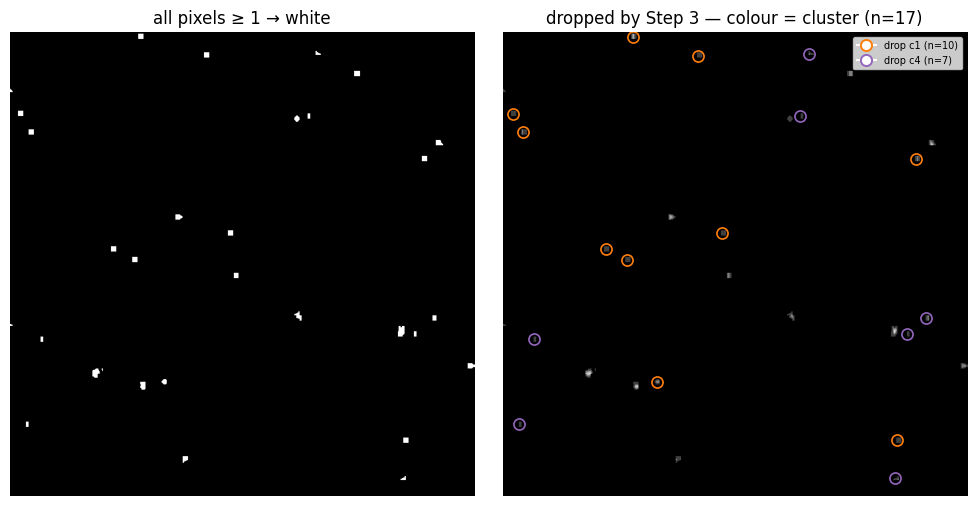

,image,roi_tag,x0,y0,size,imagej_macro,improved,nn_clean,nn_dropped,delta_improved_minus_nn,artifact_clusters,drop_cluster_1,drop_cluster_4
0,LBS255611.jpg,step1_three_color,700,1400,700,23,48,33,15,15,"[1, 4]",4,11
1,LBS255611.jpg,dense,400,2800,700,16,56,44,12,12,"[1, 4]",3,9
2,LBS255611.jpg,max_disagreement,2800,200,700,27,28,11,17,17,"[1, 4]",10,7


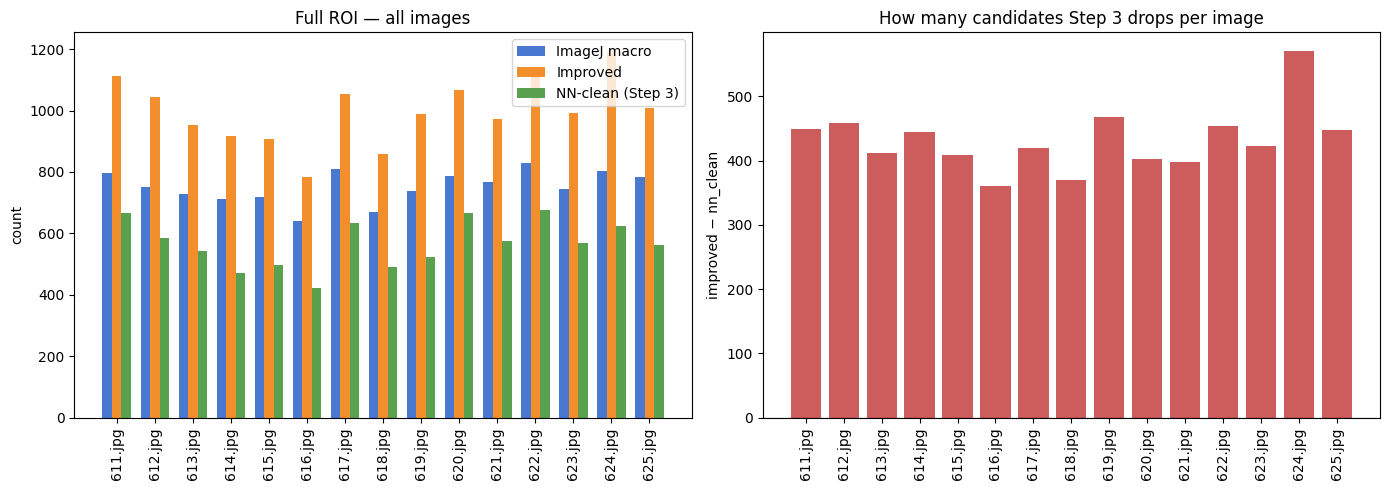

Saved step4_roi_comparison.csv, step4_per_image_comparison.csv, step4_*.png
ARTIFACT_CLUSTERS = [1, 4]
Red markers / bars = what Step 3 removes vs improved macro. Inspect whether they look like specks or real tracks.


In [80]:
# 4.1 — ROI helpers and per-ROI confrontation (Step 3 vs improved macro)
STEP4_IMG = 0
STEP4_SIZE = 700
STEP4_GRID = 200
STEP4_STRETCH = 8

# consistent cluster colours (same as Step 3 t-SNE / montages)
_CLUSTER_CMAP = plt.cm.tab10
def _cluster_color(cl):
    return _CLUSTER_CMAP(int(cl) % 10)

def _drop_legend_handles(dropped_df, include_keep=True):
    from matplotlib.lines import Line2D
    handles = []
    if include_keep:
        handles.append(Line2D([0], [0], marker="o", color="w", markeredgecolor="blue",
                              markersize=8, mew=1.4, label="NN keep"))
    for cl in sorted(dropped_df["cluster"].unique()):
        n = int((dropped_df["cluster"] == cl).sum())
        handles.append(Line2D([0], [0], marker="o", color="w",
                              markeredgecolor=_cluster_color(cl), markersize=8, mew=1.4,
                              label=f"drop c{int(cl)} (n={n})"))
    return handles

def _macro_centroids_crop(crop):
    lbl = measure.label(crop >= CFG.macro_thresh, connectivity=2)
    pts = []
    for p in measure.regionprops(lbl):
        if (CFG.macro_size_min <= p.area <= CFG.macro_size_max and
                CFG.macro_circ_min <= _circularity(p.area, p.perimeter) <= CFG.macro_circ_max):
            pts.append((p.centroid[1], p.centroid[0]))
    return np.asarray(pts).reshape(-1, 2)

def _pick_roi(meta_df, roi_h, roi_w, size, mode="dense"):
    """Return (score, x0, y0, tag) for a STEP4_SIZE window inside the ROI."""
    best = None
    for y0 in range(0, roi_h - size, STEP4_GRID):
        for x0 in range(0, roi_w - size, STEP4_GRID):
            in_w = ((meta_df["cx"] >= x0) & (meta_df["cx"] < x0 + size) &
                    (meta_df["cy"] >= y0) & (meta_df["cy"] < y0 + size))
            n_imp = int(in_w.sum())
            n_nn = int((in_w & meta_df["is_track"]).sum())
            score = n_imp if mode == "dense" else (n_imp - n_nn)
            if best is None or score > best[0]:
                best = (score, x0, y0)
    tag = "dense" if mode == "dense" else "max_disagreement"
    return best[0], best[1], best[2], tag

def _candidates_in_roi(meta_df, image, x0, y0, size):
    m = ((meta_df["image"] == image) &
         (meta_df["cx"] >= x0) & (meta_df["cx"] < x0 + size) &
         (meta_df["cy"] >= y0) & (meta_df["cy"] < y0 + size))
    return meta_df.loc[m].copy()

def confront_roi(image_name, roi, meta_df, x0, y0, size, tag, save=True):
    """Build figures + one summary row for a single ROI window."""
    crop = roi[y0:y0 + size, x0:x0 + size]
    stretch = np.clip(crop.astype(int) * STEP4_STRETCH, 0, 255)
    noise = np.where(crop >= 1, 255, 0).astype(np.uint8)
    cands = _candidates_in_roi(meta_df, image_name, x0, y0, size)
    n_macro = len(_macro_centroids_crop(crop))
    n_improved = len(cands)
    n_nn = int(cands["is_track"].sum())
    n_dropped = n_improved - n_nn

    # --- Figure A: count bars for this ROI ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    ax = axes[0, 0]
    methods = ["ImageJ\nmacro", "Improved\n(all)", "NN-clean\n(Step 3)"]
    counts = [n_macro, n_improved, n_nn]
    colors = ["#4878cf", "#f28e2b", "#59a14f"]
    ax.bar(methods, counts, color=colors)
    ax.set_ylabel("count in ROI"); ax.set_title(f"{tag} ROI — {image_name} ({size}×{size})")
    for i, v in enumerate(counts):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=11)

    # --- Figure B: disagreement overlay (blue=NN keeps, colour by cluster for drops) ---
    ax = axes[0, 1]
    ax.imshow(stretch, cmap="gray")
    n_blue = 0
    dropped = cands[~cands["is_track"]]
    for _, r in cands.iterrows():
        x, y = r["cx"] - x0, r["cy"] - y0
        if r["is_track"]:
            ax.plot(x, y, "o", mfc="none", mec="blue", ms=9, mew=1.4); n_blue += 1
        else:
            ax.plot(x, y, "o", mfc="none", mec=_cluster_color(r["cluster"]), ms=9, mew=1.4)
    n_red = len(dropped)
    ax.set_title(f"blue = NN keeps ({n_blue}) · colours = dropped by cluster ({n_red})")
    if len(dropped):
        ax.legend(handles=_drop_legend_handles(dropped), fontsize=7, loc="upper right")
    ax.axis("off")

    # --- Figure C: waterfall — NN drops by cluster ---
    ax = axes[1, 0]
    if len(dropped):
        by_cl = dropped.groupby("cluster").size().sort_index()
        bar_cols = [_cluster_color(c) for c in by_cl.index]
        ax.bar([f"c{int(c)}" for c in by_cl.index], by_cl.values, color=bar_cols)
        ax.set_xlabel("artifact cluster"); ax.set_ylabel(f"dropped in ROI (total {n_red})")
        ax.set_title("NN drops by cluster")
    else:
        ax.text(0.5, 0.5, "no NN drops in this ROI", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("NN drops by cluster"); ax.axis("off")

    # --- Figure D: morphology scatter (area vs eccentricity) ---
    ax = axes[1, 1]
    if len(cands):
        keep = cands[cands["is_track"]]
        drop = cands[~cands["is_track"]]
        if len(keep):
            ax.scatter(keep["ecc"], keep["area"], c="blue", s=28, alpha=0.7, label=f"NN keep ({len(keep)})")
        for cl, grp in drop.groupby("cluster"):
            ax.scatter(grp["ecc"], grp["area"], c=[_cluster_color(cl)], s=28, alpha=0.75,
                       label=f"drop c{int(cl)} ({len(grp)})")
        ax.set_xlabel("eccentricity"); ax.set_ylabel("area (px)")
        ax.set_title("morphology: kept vs dropped"); ax.legend(fontsize=7)
    else:
        ax.axis("off")

    fig.suptitle(f"Step 4 — {tag} ROI @ ({x0},{y0})", y=1.01)
    plt.tight_layout()
    if save:
        fig.savefig(CFG.out_dir / f"step4_{tag}_roi.png", dpi=120, bbox_inches="tight")
    plt.show()

    # --- small inset: noise map ---
    fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
    ax2[0].imshow(noise, cmap="gray", vmin=0, vmax=255)
    ax2[0].set_title("all pixels ≥ 1 → white"); ax2[0].axis("off")
    ax2[1].imshow(stretch, cmap="gray")
    for _, r in dropped.iterrows():
        ax2[1].plot(r["cx"] - x0, r["cy"] - y0, "o", mfc="none",
                    mec=_cluster_color(r["cluster"]), ms=8, mew=1.2)
    ax2[1].set_title(f"dropped by Step 3 — colour = cluster (n={n_red})")
    if len(dropped):
        ax2[1].legend(handles=_drop_legend_handles(dropped, include_keep=False), fontsize=7, loc="upper right")
    ax2[1].axis("off")
    plt.tight_layout()
    if save:
        fig2.savefig(CFG.out_dir / f"step4_{tag}_drops.png", dpi=120, bbox_inches="tight")
    plt.show()

    drop_by_cluster = dropped.groupby("cluster").size().to_dict() if len(dropped) else {}
    return {
        "image": image_name, "roi_tag": tag, "x0": x0, "y0": y0, "size": size,
        "imagej_macro": n_macro, "improved": n_improved, "nn_clean": n_nn,
        "nn_dropped": n_dropped, "delta_improved_minus_nn": n_improved - n_nn,
        "artifact_clusters": str(ARTIFACT_CLUSTERS),
        **{f"drop_cluster_{int(k)}": int(v) for k, v in drop_by_cluster.items()},
    }

def _get_step1_overlay_roi():
    """Same ROI as step1_overlay_three_color.png (reuse STEP1_OVERLAY_ROI or recompute Step-1 logic)."""
    if "STEP1_OVERLAY_ROI" in globals() and STEP1_OVERLAY_ROI:
        return STEP1_OVERLAY_ROI
    name = IMAGES[0].name
    roi0 = load_roi(IMAGES[0])
    labels0, _ = detect_cache[name]
    step = 700
    best, by, bx = -1, 0, 0
    occ = labels0 > 0
    for yy in range(0, roi0.shape[0] - step, step):
        for xx in range(0, roi0.shape[1] - step, step):
            s = int(occ[yy:yy + step, xx:xx + step].sum())
            if s > best:
                best, by, bx = s, yy, xx
    print("Note: STEP1_OVERLAY_ROI not found — recomputed from Step-1 overlay logic.")
    return dict(image=name, y0=int(by), x0=int(bx), size=int(step))

def _load_roi_by_name(image_name):
    for p in IMAGES:
        if p.name == image_name:
            return load_roi(p)
    raise ValueError(f"image not in IMAGES: {image_name}")

# --- run confrontations ---
roi_rows = []

# 1) Same ROI as step1_overlay_three_color.png (run Step 1 first for identical coordinates)
s1 = _get_step1_overlay_roi()
print(f"step1_three_color ROI: {s1['image']}  x0={s1['x0']} y0={s1['y0']} size={s1['size']}")
roi_rows.append(confront_roi(
    s1["image"], _load_roi_by_name(s1["image"]), meta,
    s1["x0"], s1["y0"], s1["size"], "step1_three_color"))

# 2) Additional ROIs on STEP4_IMG (may differ from Step 1 window)
img_name = IMAGES[STEP4_IMG].name
roi = load_roi(IMAGES[STEP4_IMG])
_m = meta[meta["image"] == img_name]

for mode in ("dense", "max_disagreement"):
    _, x0, y0, tag = _pick_roi(_m, CFG.roi_h, CFG.roi_w, STEP4_SIZE, mode=mode)
    print(f"{tag}: {img_name}  x0={x0} y0={y0}  (score window)")
    roi_rows.append(confront_roi(img_name, roi, meta, x0, y0, STEP4_SIZE, tag))

roi_df = pd.DataFrame(roi_rows)
roi_df.to_csv(CFG.out_dir / "step4_roi_comparison.csv", index=False)
display(roi_df)

# --- per-image sheet-level comparison (all 15 images) ---
sheet = final[["image", "imagej_count", "improved", "nn_clean_count"]].copy()
sheet = sheet.rename(columns={"nn_clean_count": "nn_clean"})
sheet["delta_improved_minus_nn"] = sheet["improved"] - sheet["nn_clean"]
sheet["delta_improved_minus_imagej"] = sheet["improved"] - sheet["imagej_count"]
sheet["nn_minus_imagej"] = sheet["nn_clean"] - sheet["imagej_count"]
sheet.to_csv(CFG.out_dir / "step4_per_image_comparison.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(sheet)); w = 0.25
ax[0].bar(x - w, sheet["imagej_count"], w, label="ImageJ macro", color="#4878cf")
ax[0].bar(x, sheet["improved"], w, label="Improved", color="#f28e2b")
ax[0].bar(x + w, sheet["nn_clean"], w, label="NN-clean (Step 3)", color="#59a14f")
ax[0].set_xticks(x); ax[0].set_xticklabels([n[-7:] for n in sheet["image"]], rotation=90)
ax[0].set_ylabel("count"); ax[0].legend(); ax[0].set_title("Full ROI — all images")

ax[1].bar(x, sheet["delta_improved_minus_nn"], color="indianred")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xticks(x); ax[1].set_xticklabels([n[-7:] for n in sheet["image"]], rotation=90)
ax[1].set_ylabel("improved − nn_clean"); ax[1].set_title("How many candidates Step 3 drops per image")
plt.tight_layout(); plt.savefig(CFG.out_dir / "step4_per_image_delta.png", dpi=120); plt.show()

print("Saved step4_roi_comparison.csv, step4_per_image_comparison.csv, step4_*.png")
print(f"ARTIFACT_CLUSTERS = {ARTIFACT_CLUSTERS}")
print("Red markers / bars = what Step 3 removes vs improved macro. Inspect whether they look like specks or real tracks.")

## Step 4 — Ground truth & precision / recall / F1

This is what turns the pipeline from "looks reasonable" into a *validated measurement*. You hand-mark
the real tracks in a small crop (the ground truth), then every detector is scored against it:

- **TP** detection matched to a GT point within `MATCH_RADIUS` px
- **FP** detection with no GT nearby (over-counting: noise/over-split)
- **FN** GT point with no detection nearby (missed track)
- **precision** = TP/(TP+FP), **recall** = TP/(TP+FN), **F1** = harmonic mean

Workflow: run the crop cell → click every track in the interactive cell → save → evaluate.
The GT is cached to CSV so you only click once.

> Methods scored: the true **macro** (size+circularity gate), the **improved** detector, the
> **NN-cleaned** set (improved minus artifact clusters), and optionally **Cellpose**.

Eval crop: LBS255611.jpg  x0=400 y0=2800 size=700  (~56 candidates inside)


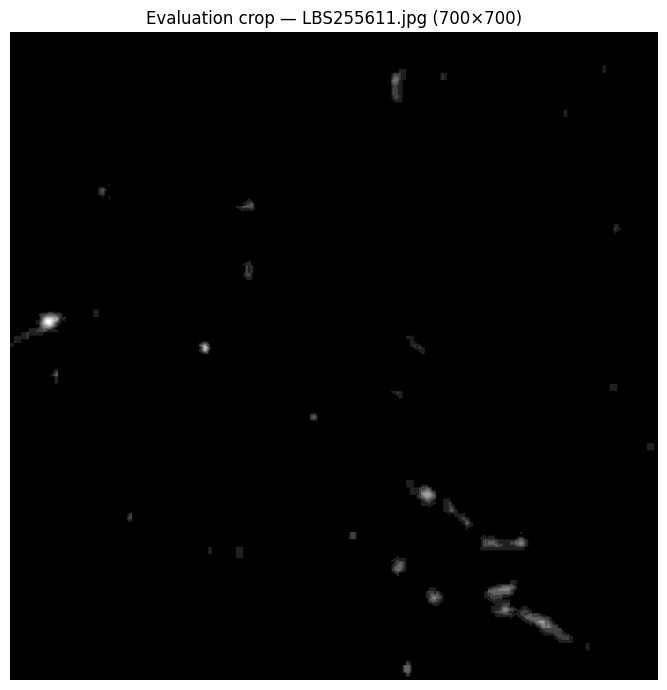

GT will be cached at: gt_LBS255611_400_2800_700.csv (not yet created)


In [59]:
# 5.1 — Choose the evaluation crop (small enough to hand-count, dense enough to be meaningful)
EVAL_IMG = 0          # index into IMAGES
EVAL_SIZE = 700       # crop side in px (~20-30 tracks here)
MATCH_RADIUS = 12     # px tolerance when matching a detection to a GT point
STRETCH = 8           # display contrast only

EVAL_NAME = IMAGES[EVAL_IMG].name
_m0 = meta[meta["image"] == EVAL_NAME]

# pick the densest EVAL_SIZE window using the candidate centroids (cheap grid search)
best = None
for Y0 in range(0, CFG.roi_h - EVAL_SIZE, 200):
    for X0 in range(0, CFG.roi_w - EVAL_SIZE, 200):
        c = int(((_m0["cx"] >= X0) & (_m0["cx"] < X0 + EVAL_SIZE) &
                 (_m0["cy"] >= Y0) & (_m0["cy"] < Y0 + EVAL_SIZE)).sum())
        if best is None or c > best[0]:
            best = (c, X0, Y0)
_, EVAL_X0, EVAL_Y0 = best
print(f"Eval crop: {EVAL_NAME}  x0={EVAL_X0} y0={EVAL_Y0} size={EVAL_SIZE}  (~{best[0]} candidates inside)")

eval_crop = load_roi(IMAGES[EVAL_IMG])[EVAL_Y0:EVAL_Y0+EVAL_SIZE, EVAL_X0:EVAL_X0+EVAL_SIZE]
GT_CSV = CFG.out_dir / f"gt_{EVAL_NAME.replace('.jpg','')}_{EVAL_X0}_{EVAL_Y0}_{EVAL_SIZE}.csv"

plt.figure(figsize=(7, 7))
plt.imshow(np.clip(eval_crop.astype(int) * STRETCH, 0, 255), cmap="gray")
plt.title(f"Evaluation crop — {EVAL_NAME} ({EVAL_SIZE}×{EVAL_SIZE})"); plt.axis("off")
plt.tight_layout(); plt.show()
print("GT will be cached at:", GT_CSV.name, "(exists)" if GT_CSV.exists() else "(not yet created)")

### Annotate (interactive)

Run the next cell, then in the figure that appears:

- **left-click** the centre of every track you can see → adds a red `+`
- **right-click** near a mistaken mark → removes the nearest one
- the title shows the running count

When done, run the **save** cell. (Requires `ipympl`; the figure is interactive only in a live
Jupyter session — it does nothing when the notebook is run head-less via `nbconvert`.)

Tip: annotate generously but conservatively — when unsure whether a faint blob is a real etched track,
your decision *defines* the ground truth, so be consistent.

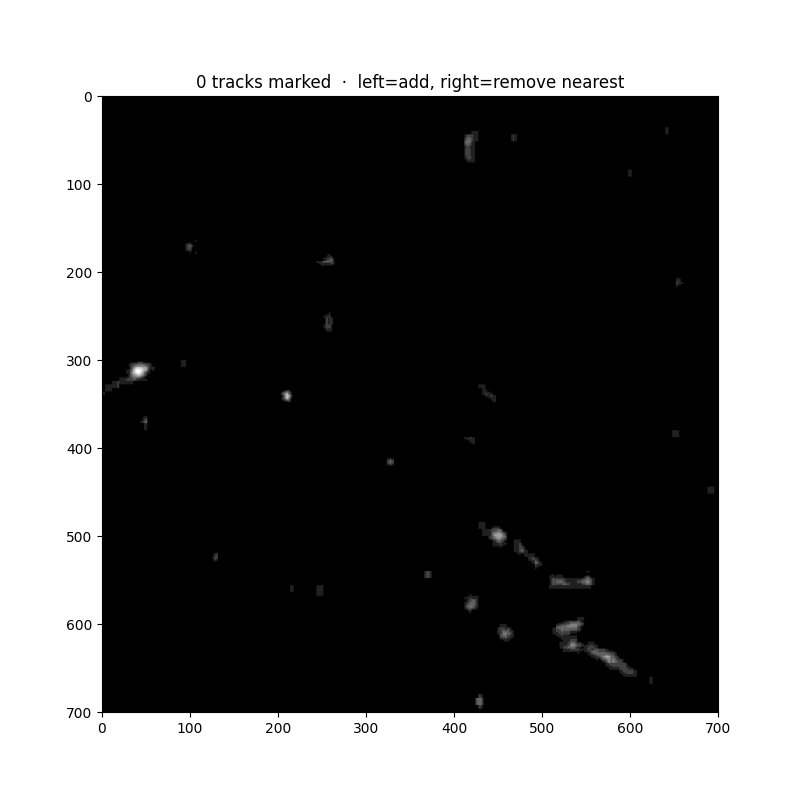

In [18]:
# 5.2 — Interactive annotator (left-click add, right-click remove nearest)
# NOTE: needs the ipympl backend. If clicks don't register, run `%matplotlib widget` in its own
# cell first, or restart the kernel after installing ipympl.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

# start from cached GT if it exists, so you can refine instead of restarting
gt_clicks = []
if GT_CSV.exists():
    _g = pd.read_csv(GT_CSV)
    gt_clicks = list(zip((_g["x_abs"] - EVAL_X0).tolist(), (_g["y_abs"] - EVAL_Y0).tolist()))
    print(f"Loaded {len(gt_clicks)} existing GT points (right-click to remove, left-click to add).")

_disp = np.clip(eval_crop.astype(int) * STRETCH, 0, 255)
_fig, _ax = plt.subplots(figsize=(8, 8))
_ax.imshow(_disp, cmap="gray")
(_pts,) = _ax.plot([], [], "r+", ms=10, mew=1.5)
_ax.set_xlim(0, EVAL_SIZE); _ax.set_ylim(EVAL_SIZE, 0)

def _redraw():
    if gt_clicks:
        xs, ys = zip(*gt_clicks); _pts.set_data(xs, ys)
    else:
        _pts.set_data([], [])
    _ax.set_title(f"{len(gt_clicks)} tracks marked  ·  left=add, right=remove nearest")
    _fig.canvas.draw_idle()

def _onclick(event):
    if event.inaxes != _ax or event.xdata is None:
        return
    if event.button == 1:
        gt_clicks.append((float(event.xdata), float(event.ydata)))
    elif event.button == 3 and gt_clicks:
        d = [(event.xdata - x) ** 2 + (event.ydata - y) ** 2 for x, y in gt_clicks]
        gt_clicks.pop(int(np.argmin(d)))
    _redraw()

_cid = _fig.canvas.mpl_connect("button_press_event", _onclick)
_redraw()

In [19]:
# 5.3 — Save the ground truth (run after you finish clicking)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

if len(gt_clicks) == 0:
    print("No GT points yet — annotate in the cell above first.")
else:
    gt_df = pd.DataFrame({
        "x_crop": [c[0] for c in gt_clicks],
        "y_crop": [c[1] for c in gt_clicks],
        "x_abs":  [c[0] + EVAL_X0 for c in gt_clicks],
        "y_abs":  [c[1] + EVAL_Y0 for c in gt_clicks],
    })
    gt_df.to_csv(GT_CSV, index=False)
    print(f"Saved {len(gt_df)} ground-truth points -> {GT_CSV}")

No GT points yet — annotate in the cell above first.


In [20]:
# 5.4 — Score every method against the ground truth
from scipy.spatial.distance import cdist

def match_metrics(gt_xy, det_xy, radius=MATCH_RADIUS):
    """Greedy nearest-neighbour matching within `radius`; returns TP/FP/FN + P/R/F1 and matches."""
    gt = np.asarray(gt_xy, float).reshape(-1, 2)
    det = np.asarray(det_xy, float).reshape(-1, 2)
    matched_gt, matched_det, tp_pairs = set(), set(), []
    if len(gt) and len(det):
        D = cdist(gt, det)
        pairs = sorted(((D[i, j], i, j) for i in range(len(gt)) for j in range(len(det))),
                       key=lambda t: t[0])
        for d, i, j in pairs:
            if d > radius:
                break
            if i in matched_gt or j in matched_det:
                continue
            matched_gt.add(i); matched_det.add(j); tp_pairs.append((i, j))
    tp = len(tp_pairs); fp = len(det) - len(matched_det); fn = len(gt) - len(matched_gt)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return dict(n_det=len(det), TP=tp, FP=fp, FN=fn,
                precision=round(prec, 3), recall=round(rec, 3), f1=round(f1, 3),
                matched_det=matched_det, matched_gt=matched_gt)

def macro_centroids(crop):
    """True macro detections (8-connectivity, size + circularity gate) in crop coords."""
    lbl = measure.label(crop >= CFG.macro_thresh, connectivity=2)
    pts = []
    for p in measure.regionprops(lbl):
        if (CFG.macro_size_min <= p.area <= CFG.macro_size_max and
                CFG.macro_circ_min <= _circularity(p.area, p.perimeter) <= CFG.macro_circ_max):
            pts.append((p.centroid[1], p.centroid[0]))  # (x, y)
    return np.array(pts).reshape(-1, 2)

# detections per method, in crop coordinates
in_win = _m0[(_m0["cx"] >= EVAL_X0) & (_m0["cx"] < EVAL_X0 + EVAL_SIZE) &
             (_m0["cy"] >= EVAL_Y0) & (_m0["cy"] < EVAL_Y0 + EVAL_SIZE)].copy()
off = np.array([EVAL_X0, EVAL_Y0])

det_sets = {
    "macro":     macro_centroids(eval_crop),
    "improved":  in_win[["cx", "cy"]].to_numpy() - off,
    "NN_clean":  in_win[in_win["is_track"]][["cx", "cy"]].to_numpy() - off,
}
if 'cellpose_segment' in dir():
    try:
        cm = cellpose_segment(eval_crop)
        det_sets["cellpose"] = np.array([(p.centroid[1], p.centroid[0])
                                         for p in measure.regionprops(cm)]).reshape(-1, 2)
    except Exception as e:
        print("cellpose eval skipped:", e)

if not GT_CSV.exists():
    print("No ground truth yet — annotate + save (cells 5.2/5.3) before scoring.")
else:
    gt = pd.read_csv(GT_CSV)[["x_crop", "y_crop"]].to_numpy()
    print(f"Ground truth: {len(gt)} tracks  |  match radius = {MATCH_RADIUS}px\n")
    results = {m: match_metrics(gt, d) for m, d in det_sets.items()}
    score = pd.DataFrame(results).T[["n_det", "TP", "FP", "FN", "precision", "recall", "f1"]]
    score.to_csv(CFG.out_dir / "step5_scores.csv")
    display(score)
    best_m = score["f1"].astype(float).idxmax()
    print(f"Best F1: '{best_m}' = {score.loc[best_m, 'f1']}")

No ground truth yet — annotate + save (cells 4.2/4.3) before scoring.


In [21]:
# 5.5 — Visualise TP / FP / FN for the chosen methods (green=TP, red=FP, yellow=FN)
if GT_CSV.exists():
    gt = pd.read_csv(GT_CSV)[["x_crop", "y_crop"]].to_numpy()
    show_methods = [m for m in ["macro", "improved", "NN_clean"] if m in det_sets]
    fig, axes = plt.subplots(1, len(show_methods), figsize=(6 * len(show_methods), 6))
    if len(show_methods) == 1:
        axes = [axes]
    for ax, m in zip(axes, show_methods):
        det = np.asarray(det_sets[m], float).reshape(-1, 2)
        r = match_metrics(gt, det)
        ax.imshow(np.clip(eval_crop.astype(int) * STRETCH, 0, 255), cmap="gray")
        md = r["matched_det"]
        for j, (x, y) in enumerate(det):
            ax.plot(x, y, "o", mfc="none", mec=("lime" if j in md else "red"), ms=9, mew=1.4)
        for i, (x, y) in enumerate(gt):
            if i not in r["matched_gt"]:
                ax.plot(x, y, "s", mfc="none", mec="yellow", ms=11, mew=1.6)
        ax.set_title(f"{m}: P={r['precision']} R={r['recall']} F1={r['f1']}\n"
                     f"TP={r['TP']} FP(red)={r['FP']} FN(yellow)={r['FN']}")
        ax.axis("off")
    plt.tight_layout(); plt.savefig(CFG.out_dir / "step5_tp_fp_fn.png", dpi=120); plt.show()
else:
    print("Annotate + save ground truth first to see the TP/FP/FN overlay.")

Annotate + save ground truth first to see the TP/FP/FN overlay.


## Conclusions & next steps

**What this notebook gives you**
- A faithful re-implementation of the macro (validates against `Summary.csv`).
- An **improved classical detector** (no circularity gate + watershed splitting) that recovers oblique
  and merged tracks the macro discards.
- A **Cellpose-SAM** baseline that splits touching tracks with zero training.
- A fully **unsupervised** autoencoder + clustering pipeline that separates tracks from artifacts and
  reveals track-type morphology — **without labelling individual tracks**.
- **Step 4 confrontation** — same-ROI visual comparison of improved macro vs NN-clean counts.
- **Step 5 ground truth** — precision/recall/F1 on a hand-marked crop.

**Outputs** are written to `algorithms/outputs/` (`final_counts.csv`, `step4_roi_comparison.csv`,
`candidates_labeled.csv`, `embeddings.npy`, and all figures).

**To make this measurement-grade**
1. **Use Step 4** to inspect red markers (what Step 3 drops). If they look like specks, Step 3 is
   working; if they look like comet tracks, narrow `ARTIFACT_CLUSTERS`.
2. **Use Step 5** to hand-mark 1–2 crops and read off precision/recall/F1 per method.
3. Revisit `ARTIFACT_CLUSTERS` after eyeballing the cluster montages (Step 3.6).
4. Physics bonus: per-cluster `ecc`/`area` profiles approximate alpha **incidence-angle / energy**
   populations — worth correlating with known exposure conditions.